In [1]:
#if fresh enviornment, in terminal
'''
chmod +x dependencies.sh
./dependencies.sh
'''
import sys
print(sys.executable)

/home/ec2-user/anaconda3/envs/python3/bin/python


In [2]:
# Install dependencies
packages = [
    "transformers",
    "datasets",
    "iterative-stratification",
    "seaborn",
    "matplotlib",
    "nltk",
    "torch",
    "ftfy",
    "Levenshtein",
    "sentencepiece",
    "sacremoses",
    "peft",
]

!pip install -q {" ".join(packages)} > /dev/null 2>&1

In [3]:
# Standard library
import copy
import gc
import glob
import itertools
import json
import math
import os
import random
import re
import warnings
from collections import Counter


# Data processing
import ftfy
import Levenshtein
import numpy as np
import pandas as pd


# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns


# NLP
import nltk
from nltk.corpus import wordnet
from nltk.tokenize.punkt import PunktSentenceTokenizer


# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer


# Multilabel stratified splitting
from iterstrat.ml_stratifiers import (
    MultilabelStratifiedKFold,
    MultilabelStratifiedShuffleSplit as MSSS,
)


# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset


# Transformers
from transformers import (
    AutoModel,
    AutoModelForSeq2SeqLM,
    AutoModelForSequenceClassification,
    AutoTokenizer,
)
from transformers.utils import logging as transformers_logging


# PEFT / LoRA
from peft import LoraConfig, TaskType, get_peft_model


# Suppress Transformers output
transformers_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()


# Suppress Hugging Face Hub progress bars
try:
    from huggingface_hub import disable_progress_bars
    disable_progress_bars()
except ImportError:
    pass


# Suppress warnings
warnings.filterwarnings("ignore")


# Download required NLTK data
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [5]:
#load data into df
#load the json training_set_task1.txt
with open("training_set_task1.txt", "r", encoding="utf-8") as f:
    data = json.load(f)

#load into pandas DataFrame
df = pd.DataFrame(data)

# Count using pandas (if 'labels' is a column containing lists)
empty_label_count = df["labels"].apply(lambda x: len(x) == 0).sum()

print(f"Number of entries with empty labels: {empty_label_count}")

#save entries with empty labels into a seperate DF for checking
empty_labels_df = df[df["labels"].map(len) == 0].copy()

#Kepp at entries, empty_labels_df is kept only for inspection
df = df.reset_index(drop=True)

print(f"Total entries in df: {len(df)}")
print(f"  with at least one label: {(df['labels'].map(len) > 0).sum()}")
print(f"  with no labels:          {len(empty_labels_df)}")


Number of entries with empty labels: 143
Valid entries saved to df: 545
Empty label entries saved to empty_labels_df: 143


In [6]:
'''
### google.colab. colab version
from google.colab import drive

#mount Drive
drive.mount("/content/drive")

#define path 'ass2' folder
folder_path = "/content/drive/MyDrive/assignment2"
file_path = os.path.join(folder_path, "training_set_task1.txt")

#load data into JSON
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

#load into pandas DataFrame
df = pd.DataFrame(data)

#count empty labels
empty_label_count = df["labels"].apply(lambda x: len(x) == 0).sum()
print(f"Number of entries with empty labels: {empty_label_count}")

#save entries with empty labels into empty_labels_df
empty_labels_df = df[df["labels"].map(len) == 0].copy()

#Keep only valid non-empty entries in df
df = df[df["labels"].map(len) > 0].copy()
'''

'\n### google.colab. colab version\nfrom google.colab import drive\n\n#mount Drive\ndrive.mount("/content/drive")\n\n#define path \'ass2\' folder\nfolder_path = "/content/drive/MyDrive/assignment2"\nfile_path = os.path.join(folder_path, "training_set_task1.txt")\n\n#load data into JSON\nwith open(file_path, "r", encoding="utf-8") as f:\n    data = json.load(f)\n\n#load into pandas DataFrame\ndf = pd.DataFrame(data)\n\n#count empty labels\nempty_label_count = df["labels"].apply(lambda x: len(x) == 0).sum()\nprint(f"Number of entries with empty labels: {empty_label_count}")\n\n#save entries with empty labels into empty_labels_df\nempty_labels_df = df[df["labels"].map(len) == 0].copy()\n\n#Keep only valid non-empty entries in df\ndf = df[df["labels"].map(len) > 0].copy()\n'

In [7]:
print(f"Valid training entries: {len(df)}")
print(f"Empty-label entries: {len(empty_labels_df)}")

Valid training entries: 545
Empty-label entries: 143


In [8]:
labels = df["labels"].apply(lambda x: x[0] if len(x) else "(no technique)")

print(df[["text", "labels"]].head())

print(labels.value_counts().sort_index())

print(labels.unique())

                                                text  \
0    THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n   
2  SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...   
3  PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...   
5  Our elders were called to war to save lives.\n...   
6  Adolf Hitler\n• Believed state power would fix...   

                                              labels  
0             [Black-and-white Fallacy/Dictatorship]  
2  [Loaded Language, Name calling/Labeling, Sloga...  
3  [Causal Oversimplification, Loaded Language, N...  
5  [Appeal to fear/prejudice, Causal Oversimplifi...  
6  [Loaded Language, Name calling/Labeling, Reduc...  
labels
Appeal to authority                                     13
Appeal to fear/prejudice                                42
Bandwagon                                                2
Black-and-white Fallacy/Dictatorship                    12
Causal Oversimplification                               21
Doubt                          

In [9]:
'''
### google.colab. save to file
from google.colab import files
folder_path = "/content/drive/MyDrive/assignment2"
df.to_csv(f"{folder_path}/training_set_task1.csv", index=False)
'''

'\n### google.colab. save to file\nfrom google.colab import files\nfolder_path = "/content/drive/MyDrive/assignment2"\ndf.to_csv(f"{folder_path}/training_set_task1.csv", index=False)\n'

In [10]:
# Class weights for imbalanced data

#get all the labels
all_labels = list(itertools.chain.from_iterable(df["labels"]))

#extract a list of unique labels, sorted
label_names = sorted(list(set(all_labels)))
#get number of classes
NUM_CLASSES = len(label_names)

#give class count
class_counts = Counter(all_labels)

#compute inverse frequency weights
total_occurrences = len(all_labels)
#iterate through 'label_names'
class_weights = torch.tensor(
    [total_occurrences / max(1, class_counts.get(name, 0)) for name in label_names],
    dtype=torch.float32
).to(device)

#normalize weights so they average to 1.0
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

#formatted results
print('Class weights (inverse frequency):')
for i, name in enumerate(label_names):
    print(f'  {name}: {class_weights[i].item():.2f}')


Class weights (inverse frequency):
  Appeal to authority: 0.63
  Appeal to fear/prejudice: 0.19
  Bandwagon: 4.09
  Black-and-white Fallacy/Dictatorship: 0.45
  Causal Oversimplification: 0.30
  Doubt: 0.17
  Exaggeration/Minimisation: 0.16
  Flag-waving: 0.30
  Glittering generalities (Virtue): 0.26
  Loaded Language: 0.02
  Misrepresentation of Someone's Position (Straw Man): 0.41
  Name calling/Labeling: 0.04
  Obfuscation, Intentional vagueness, Confusion: 2.04
  Presenting Irrelevant Data (Red Herring): 8.17
  Reductio ad hitlerum: 0.91
  Repetition: 1.02
  Slogans: 0.19
  Smears: 0.04
  Thought-terminating cliché: 0.41
  Whataboutism: 0.20


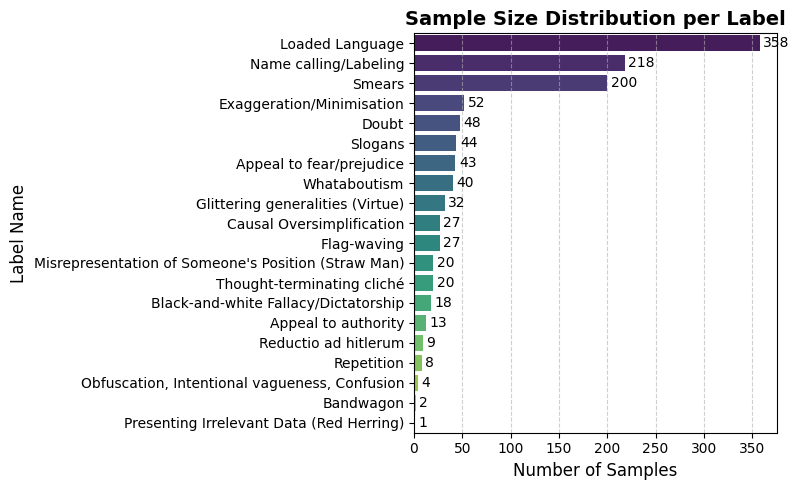

In [11]:
# Extract labels and counts sorted by frequency
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_counts)

# Create plot
#plt.figure(figsize=(10, len(labels) * 0.4 + 2))
plt.figure(figsize=(8, 5))
sns.barplot(x=list(counts), y=list(labels), hue=list(labels), palette="viridis", legend=False)

plt.xlabel("Number of Samples", fontsize=12)
plt.ylabel("Label Name", fontsize=12)
plt.title("Sample Size Distribution per Label", fontsize=14, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.6)

# Annotate bars with exact counts
for index, count in enumerate(counts):
    plt.text(count + (max(counts) * 0.01), index, f"{count:,}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

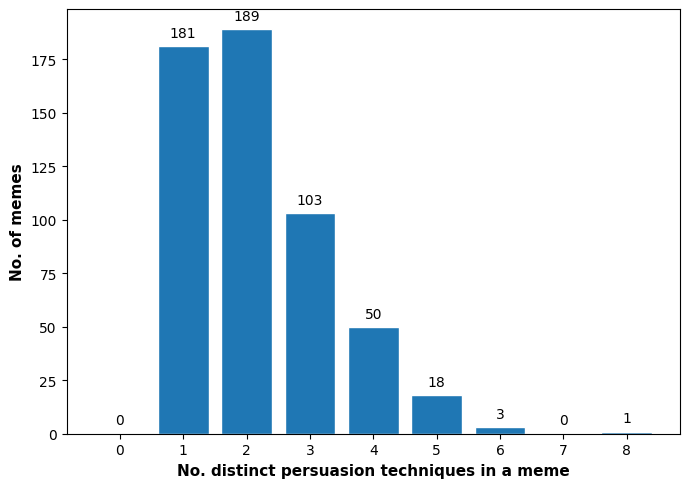

In [12]:
### for Task 1 ###
#get distinct techniques
distinct_counts = df['labels'].apply(lambda x: len(set(x)) if isinstance(x, (list, set, tuple)) else (1 if pd.notna(x) else 0))
#freq distr
distribution = distinct_counts.value_counts()

max_techniques = distribution.index.max() if len(distribution) > 0 else 0
distribution = distribution.reindex(range(0, max_techniques + 1), fill_value=0)

#chart
x_values = distribution.index
y_values = distribution.values
plt.figure(figsize=(7, 5))
bars = plt.bar(x_values, y_values, color='#1f77b4', edgecolor='white')
#format labels
plt.xlabel("No. distinct persuasion techniques in a meme", fontsize=11, fontweight="bold")
plt.ylabel("No. of memes", fontsize=11, fontweight="bold")
plt.xticks(x_values)
# show counts for each bar
max_y = max(y_values) if len(y_values) > 0 else 1
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (max_y * 0.015),
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()



In [13]:
#pick and print one sample 'text' for each unique label
print("Sample text per label:")
for label in label_names:
    # Filter for rows where 'label' is in the row's list of labels
    matching_rows = df[df["labels"].apply(lambda labels: label in labels)]

    if not matching_rows.empty:
        # Get the 'text' of the first matching sample
        sample_text = matching_rows.iloc[0]["text"]
        print(f"\n--- Label: {label} ---")
        print(sample_text)
    else:
        print(f"\n--- Label: {label} ---")
        print("[No matching sample found]")

Sample text per label:

--- Label: Appeal to authority ---
"If a law is unjust, a man is not only right to disobey it, he is obligated to do so."
 -Thomas Jefferson


--- Label: Appeal to fear/prejudice ---
Our elders were called to war to save lives.
We are being called to sit on the couch to save theirs.
We can do this.


--- Label: Bandwagon ---
If you support this man, I won't judge you for your choice of political parties. 
I will judge you for your lack of morals, ethics and humanity.
So will others.
So will history.


--- Label: Black-and-white Fallacy/Dictatorship ---
THERE ARE ONLY TWO GENDERS

FEMALE 

MALE


--- Label: Causal Oversimplification ---
PATHETIC

The Cowardly Asshole
Weak Failure!!!

Impeach it again!!!

# 45 the coward s afraid of strong women!!

POLITICUSUSA.COM
Childish Trump Won't Meet With Pelosi On Coronavirus
Because He Doesn't Like Her


--- Label: Doubt ---
Reminder: This building in Oklahoma City was blown up and destroyed just 4 days before Hillary Cli

* Looking at the samples from each category, the task requires contextual understanding, where the order of the words matters, rather than simple keyword matching. Therefore, a Bag-of-Words approach may not be suitable, as it does not capture the relationships between words. A self-attention approach can better capture these contextual relationships and dependencies within the text. A transformer approach would be ideal.

* Given that there are only 545 training samples, using a model pre-trained on a large text corpus would be beneficial. A pre-trained model should be able to  capture aspects of grammar and sentiment, reducing the amount of data that is required to learn these patterns compared with training a model from scratch.

* Furthermore, to maximise performance given the small dataset, 5-fold cross-validation can be used. MultilabelStratifiedKFold divides the dataset into five folds while maintaining a similar distribution of the rare classes across each fold. Five separate model instances are then trained, with each model using four folds for training and the remaining fold for validation. The predictions from the five models can then be averaged to produce the final prediction.


* There is large label disparity.. The dataset is imbalanced, with labels such as "Loaded Language", "Name Calling/Labeling" and "Smears" accounting for a large proportion of the training samples with > than 25% of the samples, labels like Bandwagon, Irrelevant Data, and Confusion are present in less than 2% of the data. As a result, standard Binary Cross-Entropy (BCE) may not adequately account for underrepresented positive labels, potentially leading to poorer performance with the minority classes. Therefore, Weighted Binary Cross-Entropy (Weighted BCE) can be used to address this imbalance by assigning higher weights to positive instances of less frequent classes, with weights inversely proportional to their frequency. This helps the model put greater weight on learning under-represented labels.

* Because the class distribution is imbalanced, Macro F1 will be used as the primary evaluation metric, as it assigns equal importance to each class and therefore provides greater sensitivity to performance on minority classes. In contrast, Micro F1 aggregates true positives, false positives, and false negatives across all classes, meaning that its score is influenced more heavily by the majority classes. Therefore, Micro F1 will be used as a supplementary metric to Macro F1 to provide additional insight into overall performance across the observed class distribution.

* From the current bechmark from, Dimitrov et al. (2021):
   * For Task 1. Team MinD archieved a F1-Micro score of .593 and .290 so this model should at least archieve the same benchmark score.
   * For Task 2. Team Volta archieved for F1: .482, Precision: .501, Recall: .464.
   * MinD did not compete on Task 2, only on Task 1 and Task 3. Volta archieved the best combination of both Task 1 and Task 2 with F1-Micro: .570 and F1-Macro .266
   * For these experiments the benchmark for both Tasks will be:
      * Task 1: F1-Micro: .570 and F1-Macro .266
      * Task 2: F1: .482, Precision: .501, Recall: .464.

* Dimitrov et al. (2021) mentions that there are biases in the training data:
That there are sizable disparities in the frequency of different techniques accross the data set.
The data set was sourced to 26 specific facebook groups, that were heavily focused on the politcics, pandamic, vaccines and gender equality. The uses of this solution may not use the same techniques or types of memes, if we solely train the model only on the SemEval-2021 Task 6 training samples.

* As the dataset may not accurately represent the data that users are likely to generate in real-world scenarios, using a pre-trained model may improve generalisation by leveraging representations learned from a broader and more diverse dataset than the available training set.

* Augmentation was used by some teams in (Dimitrov et al., 2021):
  * Such as by Team LIIR which used paraphrased augmentations of the orginal meme with back tranlsation where the text is translated to another language and then back again.
  * Team LeCun (Da San Martino et al., 2020) merged the data set with the additional external news/text propaganda dataset, aswell as multi step back translation between English, Dutch, Russian and English - thr process from (Daval-Frerot & Weis, 2020). A Clear back translation process is mentioned by Team LIIR (Ghadery et al., 2021) where they paraphrased each original sentence by translating it into a target language and then translating it back to the original language, English to German and back again.

* Becuase the data set is small to increase the size, the PTC corpus ( which has more than 20,000 sentences) from SemEval-2020 task 11 (Da San Martino et al., 2020) can be included. It was used in MinD ensamble approach (Tian et al., 2021). A subset of the data was retrived from (https://zenodo.org/records/3952415). MinD uses a process (sentence-level annotations) where they extract the label sample from the article with the start and end positions.

* For Task 1 (Gupta et al., 2021) Volta uses transfer learning with small and large variants of models - BERT and RoBERTa.

* For Task 1 (Tian et al., 2021) MinD uses transfer learninig with pretrained model RoBERTa, that has the advantage of dynamic masking and Byte-Pair Encoding (BPE) (Sennrich et al., 2016), it archieves a F1-Micro score of 0.6478 on the dev data set. They however use an ensemble by averaging the predictions across RoBERTa, XLNet, DeBERTa, and ALBERT for Task 1.




In [14]:
print(df.head())

    id                                             labels  \
0  128             [Black-and-white Fallacy/Dictatorship]   
2   96  [Loaded Language, Name calling/Labeling, Sloga...   
3  154  [Causal Oversimplification, Loaded Language, N...   
5  169  [Appeal to fear/prejudice, Causal Oversimplifi...   
6  145  [Loaded Language, Name calling/Labeling, Reduc...   

                                                text  
0    THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n  
2  SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...  
3  PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...  
5  Our elders were called to war to save lives.\n...  
6  Adolf Hitler\n• Believed state power would fix...  


In [15]:
# Valid class headings
df_labels = [
    "Appeal to authority",
    "Appeal to fear/prejudice",
    "Black-and-white Fallacy/Dictatorship",
    "Causal Oversimplification",
    "Doubt",
    "Exaggeration/Minimisation",
    "Flag-waving",
    "Glittering generalities (Virtue)",
    "Loaded Language",
    "Misrepresentation of Someone's Position (Straw Man)",
    "Name calling/Labeling",
    "Obfuscation, Intentional vagueness, Confusion",
    "Presenting Irrelevant Data (Red Herring)",
    "Reductio ad hitlerum",
    "Repetition",
    "Slogans",
    "Smears",
    "Thought-terminating cliché",
    "Whataboutism",
    "Bandwagon",
    "Transfer",
    "Appeal to (Strong) Emotions"
]
label_lookup = {label: label for label in df_labels}

In [16]:
#show the class counts of DF (training_set_task1.txt)
label_counts = (
    df["labels"]
    .dropna()
    .explode()
    .map(lambda x: label_lookup.get(x, x))
    .dropna()
    .value_counts()
    .reindex(df_labels, fill_value=0)
)

print(label_counts)

labels
Appeal to authority                                     13
Appeal to fear/prejudice                                43
Black-and-white Fallacy/Dictatorship                    18
Causal Oversimplification                               27
Doubt                                                   48
Exaggeration/Minimisation                               52
Flag-waving                                             27
Glittering generalities (Virtue)                        32
Loaded Language                                        358
Misrepresentation of Someone's Position (Straw Man)     20
Name calling/Labeling                                  218
Obfuscation, Intentional vagueness, Confusion            4
Presenting Irrelevant Data (Red Herring)                 1
Reductio ad hitlerum                                     9
Repetition                                               8
Slogans                                                 44
Smears                                           

* Stratified splitting requires that there is at least 2 samples per class, the following classes only have a single sample:           1
   * Presenting Irrelevant Data (Red Herring)                 1    
* Data Augmentation can solve this and adding more samples, Adding the samples from the PTC data set for the to try and obtain a better balance        

In [17]:
# -----------------------------
# Create normalised text keys
# -----------------------------
'''
positive_sentences_df["text_key"] = (
    positive_sentences_df["sentence_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)'''

df["text_key"] = (
    df["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [18]:
#process used in Ng et al. (2019) subsequently used in (Ghadery et al., 2021) - 
#"LIIR at SemEval-2021 task 6: Detection of Persuasion Techniques In Texts and Images using CLIP features"


# 1. Translation helper using Facebook WMT19 models
def translate(text, model_name, sample=False):
    # Use Auto classes as WMT19 uses FSMT architecture, not Marian
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    
    # Introduce sampling to create variation rather than exact literal matches
    if sample:
        outputs = model.generate(
            **inputs, 
            do_sample=True, 
            temperature=0.8, 
            top_p=0.9,
            max_new_tokens=50
        )
    else:
        outputs = model.generate(**inputs, max_new_tokens=50)
        
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Run back-translation using the models referenced in the paper
original = "If Trump isn't Hitler, Then I'm a Moron"

# English to German (Standard generation)
german = translate(original, "facebook/wmt19-en-de")

# German back to English (Enable sampling here to force varied phrasing)
back_translated = translate(german, "facebook/wmt19-de-en", sample=True)

print(f"German: {german}")
print(f"Back-translated: {back_translated}\n")

# 2. Validation Metrics
edit_distance = Levenshtein.distance(original, back_translated)

bleu_score = nltk.translate.bleu_score.sentence_bleu(
    [original.lower().split()], 
    back_translated.lower().split(),
    weights=(0.5, 0.5, 0, 0)
)

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform([original, back_translated])
semantic_similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

print(f"Original: {original}")
print(f"Paraphrase: {back_translated}")
print(f"Edit Distance: {edit_distance}")
print(f"BLEU Overlap: {bleu_score:.4f}")
print(f"Semantic Similarity: {semantic_similarity:.4f}")

German: Wenn Trump nicht Hitler ist, dann bin ich ein Idiot
Back-translated: If Trump isn't Hitler, then I'm an idiot

Original: If Trump isn't Hitler, Then I'm a Moron
Paraphrase: If Trump isn't Hitler, then I'm an idiot
Edit Distance: 6
BLEU Overlap: 0.7319
Semantic Similarity: 0.6328


In [19]:
# Process used in Ng et al. (2019), subsequently used in (Ghadery et al., 2021)
# "LIIR at SemEval-2021 task 6: Detection of Persuasion Techniques In Texts and Images using CLIP features"

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers.utils import logging as transformers_logging

# Suppress Transformers output
transformers_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()


def get_wordnet_pos(tag):
    """Maps NLTK POS tags to WordNet POS tags."""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    return None


def substitute_synonyms(text, replacement_prob=0.20):
    """
    Replaces words in a sentence with random WordNet synonyms based on POS tags.
    replacement_prob controls the probability (e.g., 20%) that an eligible word gets swapped.
    """
    words = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(words)

    new_words = []
    for word, tag in pos_tags:
        wn_pos = get_wordnet_pos(tag)

        # Skip short words, punctuation, or non-matching POS tags
        if wn_pos and len(word) > 2 and random.random() < replacement_prob:
            synsets = wordnet.synsets(word, pos=wn_pos)
            lemmas = [
                l.name().replace('_', ' ')
                for s in synsets
                for l in s.lemmas()
                if l.name().lower() != word.lower()
            ]

            if lemmas:
                new_words.append(random.choice(lemmas))
                continue

        new_words.append(word)

    return " ".join(new_words)


# -------------------------------------------------------------------
# Load translation models once
# -------------------------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"

en_de_model_name = "facebook/wmt19-en-de"
de_en_model_name = "facebook/wmt19-de-en"

# English -> German
en_de_tokenizer = AutoTokenizer.from_pretrained(en_de_model_name)
en_de_model = AutoModelForSeq2SeqLM.from_pretrained(en_de_model_name).to(device)
en_de_model.eval()

# German -> English
de_en_tokenizer = AutoTokenizer.from_pretrained(de_en_model_name)
de_en_model = AutoModelForSeq2SeqLM.from_pretrained(de_en_model_name).to(device)
de_en_model.eval()


def translate_batch(texts, tokenizer, model, sample=False):
    """Translates a batch using an already-loaded model."""
    
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.inference_mode():
        if sample:
            outputs = model.generate(
                **inputs,
                do_sample=True,
                temperature=0.8,
                top_p=0.9,
                max_new_tokens=64
            )
        else:
            outputs = model.generate(
                **inputs,
                max_new_tokens=64
            )

    return tokenizer.batch_decode(
        outputs,
        skip_special_tokens=True
    )


# -------------------------------------------------------------------
# Process in batches
# -------------------------------------------------------------------

batch_size = 16
augmented_rows = []

for i in range(0, len(df), batch_size):
    batch_df = df.iloc[i:i + batch_size]
    original_texts = batch_df['text'].tolist()

    # English -> German
    german_texts = translate_batch(
        original_texts,
        en_de_tokenizer,
        en_de_model,
        sample=False
    )

    # German -> English
    paraphrased_texts = translate_batch(
        german_texts,
        de_en_tokenizer,
        de_en_model,
        sample=True
    )

    # Apply synonym replacement across the paraphrased batch
    final_texts = [
        substitute_synonyms(text, replacement_prob=0.20)
        for text in paraphrased_texts
    ]

    # Reconstruct augmented rows preserving original labels
    for (_, row), final_text in zip(batch_df.iterrows(), final_texts):
        augmented_rows.append({
            'id': f"{row['id']}_aug_de",
            'labels': row['labels'],
            'text': final_text,
            'text_key': (
                f"{row['text_key']}_aug_de"
                if pd.notna(row['text_key'])
                else f"{row['id']}_aug_de"
            )
        })


# -------------------------------------------------------------------
# Combine original and augmented data
# -------------------------------------------------------------------

# df_combined = pd.concat(
#     [df, pd.DataFrame(augmented_rows)],
#     ignore_index=True
# )

In [20]:
def verify_augmentation(df_original, augmented_data):
    """
    Compares original and augmented texts row-by-row to verify differences.
    
    Parameters:
    - df_original: pandas.DataFrame (the original input dataframe)
    - augmented_data: list or pandas.DataFrame (the generated augmented rows)
    
    Returns:
    - comparison_df: pandas.DataFrame with side-by-side comparison and metrics
    """
    # Convert augmented_data list to DataFrame if necessary
    if isinstance(augmented_data, list):
        df_aug = pd.DataFrame(augmented_data)
    else:
        df_aug = augmented_data.copy()
        
    # Build side-by-side comparison DataFrame
    comparison_df = pd.DataFrame({
        'original_id': df_original['id'].values,
        'augmented_id': df_aug['id'].values,
        'original_text': df_original['text'].values,
        'augmented_text': df_aug['text'].values,
    })
    
    # Check for exact string matches (ignoring leading/trailing whitespace)
    comparison_df['is_exact_match'] = (
        comparison_df['original_text'].str.strip() == comparison_df['augmented_text'].str.strip()
    )
    
    # Measure character-level edit distance
    comparison_df['edit_distance'] = [
        Levenshtein.distance(orig, aug) 
        for orig, aug in zip(comparison_df['original_text'], comparison_df['augmented_text'])
    ]
    
    # Calculate summary metrics
    total_samples = len(comparison_df)
    exact_matches = comparison_df['is_exact_match'].sum()
    unique_paraphrases = total_samples - exact_matches
    uniqueness_rate = (unique_paraphrases / total_samples) * 100 if total_samples > 0 else 0
    avg_edit_dist = comparison_df['edit_distance'].mean()
    
    # Print summary report
    print("=== Augmentation Verification Report ===")
    print(f"Total samples evaluated:     {total_samples}")
    print(f"Successfully paraphrased:    {unique_paraphrases} ({uniqueness_rate:.2f}%)")
    print(f"Identical texts remaining:   {exact_matches} ({100 - uniqueness_rate:.2f}%)")
    print(f"Average edit distance:       {avg_edit_dist:.2f} characters\n")
    
    if exact_matches > 0:
        print(f"⚠️  Notice: {exact_matches} text(s) did not change during back-translation.")
    else:
        print("✅ Success: All augmented texts are distinct from the original entries!")
        
    return comparison_df

# --- Usage Example (Run directly after Option 2) ---
comparison_results = verify_augmentation(df, augmented_rows)

# View all identical entries (if any exist):
duplicates = comparison_results[comparison_results['is_exact_match']]
print(duplicates[['original_id', 'original_text', 'augmented_text']])

=== Augmentation Verification Report ===
Total samples evaluated:     545
Successfully paraphrased:    542 (99.45%)
Identical texts remaining:   3 (0.55%)
Average edit distance:       50.53 characters

⚠️  Notice: 3 text(s) did not change during back-translation.
     original_id                         original_text  \
49            93  The Real Virus Threatening America\n   
331  447_batch_2                       TRUMP SCARES ME   
523  924_batch_2  HUNTER BIDEN SAYS WHITE LINES MATTER   

                           augmented_text  
49     The Real Virus Threatening America  
331                       TRUMP SCARES ME  
523  HUNTER BIDEN SAYS WHITE LINES MATTER  


In [21]:
#drop the few that are not the same
df_aug = pd.DataFrame(augmented_rows)
df_aug_filtered = df_aug[~comparison_results['is_exact_match']].copy()


display(df_aug_filtered.head())

,id,labels,text,text_key
0,128_aug_de,[Black-and-white Fallacy/Dictatorship],THERE ar ONLY 2 GENTER MEN,THERE ARE ONLY TWO GENDERS FEMALE MALE_aug_de
1,96_aug_de,"[Loaded Language, Name calling/Labeling, Sloga...",SO BERNIE BROS HAVE NO VIOLENCE EXCEPT ? shuff...,SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH? ...
2,154_aug_de,"[Causal Oversimplification, Loaded Language, N...",PATHETICsThe Cowardly AssholeWeak Failure ! ! ...,PATHETIC The Cowardly Asshole Weak Failure!!! ...
3,169_aug_de,"[Appeal to fear/prejudice, Causal Oversimplifi...",Our senior were call to the war to salvage liv...,Our elders were called to war to save lives. W...
4,145_aug_de,"[Loaded Language, Name calling/Labeling, Reduc...",Adolf Hitler • Believed that state power would...,Adolf Hitler • Believed state power would fix ...


In [22]:
#combine unique augmented to 
df_augmented_combined = pd.concat([df, df_aug_filtered], ignore_index=True)

print(f"Original dataset size: {len(df)}")
print(f"Filtered augmented samples added: {len(df_aug_filtered)}")
print(f"Final combined dataset size: {len(df_augmented_combined)}")

Original dataset size: 545
Filtered augmented samples added: 542
Final combined dataset size: 1087


In [23]:
# ------------------------------------------------------------------------------
# 3. Dataset & Model Definition
# ------------------------------------------------------------------------------
class FeatureDataset(Dataset):
    def __init__(self, features, labels):
        self.x = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

class LinearProbe(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.linear = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.linear(x)

# ------------------------------------------------------------------------------
# 4. Metric Utilities & Training Functions
# ------------------------------------------------------------------------------
def f1_stats(y_true, y_pred):
    """
    Calculate multilabel classification metrics.

    Returns:
        macro_f1
        micro_f1
        exact_match
        accuracy
        per_class_f1
    """
    tp = (y_true * y_pred).sum(axis=0)
    fp = ((1 - y_true) * y_pred).sum(axis=0)
    fn = (y_true * (1 - y_pred)).sum(axis=0)

    den = 2 * tp + fp + fn

    per_class = np.divide(
        2 * tp,
        den,
        out=np.zeros_like(den, dtype=np.float64),
        where=den > 0
    )

    # Only include classes that actually occur in y_true
    observed = y_true.sum(axis=0) > 0

    if observed.any():
        macro_f1 = per_class[observed].mean()
    else:
        macro_f1 = 0.0

    micro_f1 = 2 * tp.sum() / max(den.sum(), 1)

    # Exact match = every label must be correct for the sample
    exact_match = (y_true == y_pred).all(axis=1).mean()

    # Bitwise multilabel accuracy
    accuracy = (y_true == y_pred).mean()

    return (
        float(macro_f1),
        float(micro_f1),
        float(exact_match),
        float(accuracy),
        per_class
    )


def best_threshold(y_true, probs):
    """
    Find the threshold that gives the highest validation Macro-F1.
    """
    scores = []

    for threshold in THRESHOLDS:
        preds = (probs >= threshold).astype(np.float32)
        macro_f1 = f1_stats(y_true, preds)[0]
        scores.append(macro_f1)

    best_idx = int(np.argmax(scores))

    return (
        float(THRESHOLDS[best_idx]),
        float(scores[best_idx])
    )

def train_one_epoch(model, loader, optimizer, criterion):
    """
    Train the model for one epoch.
    """
    model.train()

    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        optimizer.zero_grad()

        # Hugging Face dictionary batch
        if isinstance(batch, dict) and "input_ids" in batch:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            ).logits

        # Standard (features, labels) batch
        else:
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = len(labels)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples
'''
def evaluate_model(model, loader, criterion, thr=None):
    model.eval()
    total_loss, total_samples = 0.0, 0
    all_logits, all_targets = [], []

    with torch.inference_mode():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * len(y)
            total_samples += len(y)

            all_logits.append(logits.cpu())
            all_targets.append(y.cpu())

    all_probs = torch.sigmoid(torch.cat(all_logits)).numpy()
    all_targets = torch.cat(all_targets).numpy()

    thr, macro = best_threshold(all_targets, all_probs)
    
    if thr is None:
        thr, _ = best_threshold(all_targets, all_probs)

    preds = (all_probs >= thr).astype(np.float32)
    macro, micro, exact, accuracy, per_class = f1_stats(all_targets, preds)


    return {
        "loss": total_loss / total_samples,
        "macro_f1": macro,
        "micro_f1": micro,
        "exact_match": exact,
        "accuracy": accuracy,
        "threshold": thr,
        "per_class_f1": per_class,
        "probs": all_probs,
        "targets": all_targets,
    }

def run_experiment(model, optimizer, criterion, train_loader, val_loader,
                   epochs=300, patience=40, name="Model"):
    history = {
        "train_loss": [], "val_loss": [],
        "val_macro": [], "val_micro": [], "val_exact": [], "val_accuracy": []
    }
    best_info = {"score": -1.0, "thr": 0.5, "epoch": 0, "state": None}
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        tl = train_one_epoch(model, train_loader, optimizer, criterion)
        val_res = evaluate_model(model, val_loader, criterion)

        vl = val_res["loss"]
        macro = val_res["macro_f1"]
        micro = val_res["micro_f1"]
        exact = val_res["exact_match"]
        acc = val_res["accuracy"]

        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["val_macro"].append(macro)
        history["val_micro"].append(micro)
        history["val_exact"].append(exact)
        history["val_accuracy"].append(acc)

        if macro > best_info["score"] + 1e-4:
            best_info.update(
                score=macro,
                thr=val_res["threshold"],
                epoch=epoch,
                state={k: v.clone() for k, v in model.state_dict().items()}
            )
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"[{name}] Early stopping at epoch {epoch}")
                break

        if epoch % 20 == 0 or epoch == 1:
            print(f"  [{name}] Epoch {epoch:3d}/{epochs} — "
                  f"Train Loss: {tl:.4f} | Val Loss: {vl:.4f} | "
                  f"Val Macro-F1: {macro:.3f} | Val Acc: {acc:.3f} | Best Thr: {val_res['threshold']:.2f}")

    # Restore best parameters
    model.load_state_dict(best_info["state"])
    return history, best_info
'''
def evaluate_model(model, loader, criterion, threshold=None):
    """
    Evaluate a model.

    If threshold is None, select the threshold that gives the
    highest Macro-F1 on the supplied data.
    """
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_probs = []
    all_labels = []

    with torch.inference_mode():
        for batch in loader:

            # Hugging Face dictionary batch
            if isinstance(batch, dict) and "input_ids" in batch:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                logits = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                ).logits

            # Standard (features, labels) batch
            else:
                inputs, labels = batch
                inputs = inputs.to(device)
                labels = labels.to(device)

                logits = model(inputs)

            loss = criterion(logits, labels)

            batch_size = len(labels)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            probs = torch.sigmoid(logits)

            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # Select threshold from validation data when no threshold is supplied
    if threshold is None:
        threshold, _ = best_threshold(all_labels, all_probs)

    all_preds = (all_probs >= threshold).astype(np.float32)

    macro_f1, micro_f1, exact_match, accuracy, per_class_f1 = f1_stats(
        all_labels,
        all_preds
    )

    return {
        "loss": total_loss / total_samples,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "exact_match": exact_match,
        "accuracy": accuracy,
        "threshold": threshold,
        "per_class_f1": per_class_f1,
        "probs": all_probs,
        "targets": all_labels,
        "preds": all_preds,
    }

def run_experiment(
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=10,
    patience=5,
    name="Model"
):
    """
    Train with early stopping based on validation Macro-F1.

    The model weights and threshold from the best validation epoch
    are restored after training.
    """

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_macro": [],
        "val_micro": [],
        "val_exact": [],
        "val_accuracy": []
    }

    best_info = {
        "epoch": 0,
        "score": -1.0,
        "thr": 0.5,
        "state": None
    }

    epochs_no_improve = 0

    # Keep an initial copy in case no epoch improves the score
    best_info["state"] = {
        k: v.detach().clone()
        for k, v in model.state_dict().items()
    }

    for epoch in range(1, epochs + 1):

        # ------------------------------------------------------------------
        # Training
        # ------------------------------------------------------------------
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        # ------------------------------------------------------------------
        # Validation
        # ------------------------------------------------------------------
        val_res = evaluate_model(
            model,
            val_loader,
            criterion,
            threshold=None
        )

        val_loss = val_res["loss"]
        val_macro = val_res["macro_f1"]
        val_micro = val_res["micro_f1"]
        val_exact = val_res["exact_match"]
        val_accuracy = val_res["accuracy"]
        val_threshold = val_res["threshold"]

        # Store history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro"].append(val_macro)
        history["val_micro"].append(val_micro)
        history["val_exact"].append(val_exact)
        history["val_accuracy"].append(val_accuracy)

        # ------------------------------------------------------------------
        # Early stopping / best model
        # ------------------------------------------------------------------
        if val_macro > best_info["score"] + 1e-4:

            best_info = {
                "epoch": epoch,
                "score": val_macro,
                "thr": val_threshold,
                "state": {
                    k: v.detach().clone()
                    for k, v in model.state_dict().items()
                }
            }

            epochs_no_improve = 0

        else:
            epochs_no_improve += 1

        # ------------------------------------------------------------------
        # Progress output
        # ------------------------------------------------------------------
        if epoch % 20 == 0 or epoch == 1:
            print(
                f"[{name}] Epoch {epoch:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Macro-F1: {val_macro:.3f} | "
                f"Val Micro-F1: {val_micro:.3f} | "
                f"Val Acc: {val_accuracy:.3f} | "
                f"Val Exact: {val_exact:.3f} | "
                f"Threshold: {val_threshold:.2f}"
            )

        # ------------------------------------------------------------------
        # Early stopping
        # ------------------------------------------------------------------
        if epochs_no_improve >= patience:
            print(
                f"[{name}] Early stopping at epoch {epoch}. "
                f"Best epoch: {best_info['epoch']}, "
                f"Best Val Macro-F1: {best_info['score']:.3f}, "
                f"Best Threshold: {best_info['thr']:.2f}"
            )
            break

    # ----------------------------------------------------------------------
    # Restore best model weights
    # ----------------------------------------------------------------------
    model.load_state_dict(best_info["state"])

    return history, best_info

def plot_experiments(results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for name, data in results.items():
        hist = data["history"]
        epochs = range(1, len(hist["train_loss"]) + 1)

        # Loss plot
        axes[0].plot(epochs, hist["train_loss"], label=f"{name} Train Loss")
        axes[0].plot(epochs, hist["val_loss"], linestyle="--", label=f"{name} Val Loss")

        # Validation F1 Metrics
        axes[1].plot(epochs, hist["val_macro"], label=f"{name} Val Macro-F1")
        axes[1].plot(epochs, hist["val_micro"], linestyle="--", label=f"{name} Val Micro-F1")

        # Validation Accuracy Metrics
        axes[2].plot(epochs, hist["val_accuracy"], label=f"{name} Bitwise Acc")
        axes[2].plot(epochs, hist["val_exact"], linestyle="--", label=f"{name} Exact Match")

    axes[0].set_title("BCE Loss"); axes[0].set_xlabel("Epoch"); axes[0].grid(True, alpha=0.3); axes[0].legend()
    axes[1].set_title("Validation F1 Scores"); axes[1].set_xlabel("Epoch"); axes[1].grid(True, alpha=0.3); axes[1].legend()
    axes[2].set_title("Validation Accuracy"); axes[2].set_xlabel("Epoch"); axes[2].grid(True, alpha=0.3); axes[2].legend()
    plt.tight_layout()
    plt.show()

In [24]:
#check the size of the number of tokens for the train dataset "df"
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# Tokenize all texts without truncating or padding
tokenized_data = tokenizer(df["text"].astype(str).tolist(), add_special_tokens=True)

# Count the tokens in each sequence
token_lengths = [len(seq) for seq in tokenized_data["input_ids"]]

# Find the absolute maximum
max_tokens = max(token_lengths)
print(f"The longest text has {max_tokens} tokens.")

# Optional: View the distribution to see if the max is just an outlier
lengths_series = pd.Series(token_lengths)
print("\nToken Length Distribution:")
print(lengths_series.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

The longest text has 142 tokens.

Token Length Distribution:
count    545.000000
mean      36.337615
std       19.966603
min        7.000000
50%       32.000000
75%       44.000000
90%       62.600000
95%       78.000000
99%      104.120000
max      142.000000
dtype: float64


In [25]:
all_results = {}
results_scores = {}
EPOCHS_AMT = 100
PATIENCE_AMT = 20
MAX_LENGTH = 128
SEED = 42
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

Extracting features...
[RoBERTa Probe (mean)] Epoch   1/100 | Train Loss: 0.8225 | Val Loss: 0.7823 | Val Macro-F1: 0.172 | Val Micro-F1: 0.182 | Val Acc: 0.290 | Val Exact: 0.000 | Threshold: 0.40
[RoBERTa Probe (mean)] Epoch  20/100 | Train Loss: 0.5267 | Val Loss: 0.6960 | Val Macro-F1: 0.272 | Val Micro-F1: 0.400 | Val Acc: 0.862 | Val Exact: 0.044 | Threshold: 0.65
[RoBERTa Probe (mean)] Early stopping at epoch 39. Best epoch: 19, Best Val Macro-F1: 0.285, Best Threshold: 0.75


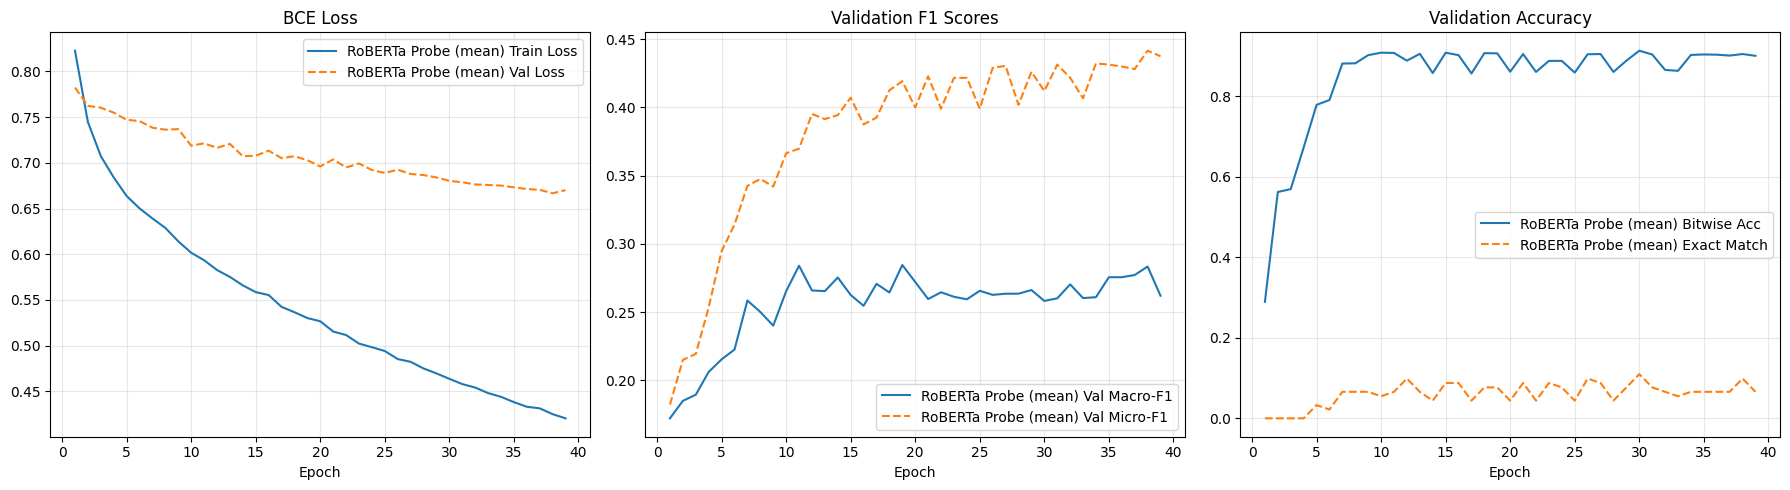


--- Final Test Evaluation ---
Best Validation Epoch: 19
Best Validation Macro-F1: 0.285
Validation Threshold:     0.75
Test Macro-F1:            0.230
Test Micro-F1:            0.309
Test Accuracy:            0.892
Test Exact Match:         0.079


In [26]:
#[1]base linear probing RoBERTa

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Split
# ------------------------------------------------------------------------------
# Filter out classes with 0 positives and ensure clean lists
observed_labels = {l for ls in df["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]

keep_set = set(CLASSES)
clean_labels = [[l for l in ls if l in keep_set] for ls in df["labels"]]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep all rows, including memes with no technique
has_label = np.ones(len(Y), dtype=bool)

Y_strat = np.hstack([Y, (Y.sum(axis=1) == 0)[:, None]])  

texts = [t for t, k in zip(df["text"].astype(str), has_label) if k]
Y = Y[has_label]

idx = np.arange(len(texts))

#MultilabelStratifiedShuffleSplit
tr, tmp = next(MSSS(n_splits=1, test_size=0.30, random_state=SEED).split(idx, Y_strat))
v, t = next(MSSS(n_splits=1, test_size=0.50, random_state=SEED).split(tmp, Y_strat[tmp]))
va, te = tmp[v], tmp[t]

X_tr_text, y_train = [texts[i] for i in tr], Y[tr]
X_va_text, y_val = [texts[i] for i in va], Y[va]
X_te_text, y_test = [texts[i] for i in te], Y[te]


# ------------------------------------------------------------------------------
# 2. Feature Extraction & Normalization
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=MAX_LENGTH, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features...")
train_feats = extract_features(X_tr_text)
val_feats = extract_features(X_va_text)
test_feats = extract_features(X_te_text)

# Choose pooling type ('mean' or 'cls')
POOLING = "mean"
X_tr, X_va, X_te = train_feats[POOLING], val_feats[POOLING], test_feats[POOLING]

# Standardize using TRAIN statistics only
mu, sd = X_tr.mean(axis=0, keepdims=True), X_tr.std(axis=0, keepdims=True) + 1e-6
X_tr_norm = (X_tr - mu) / sd
X_va_norm = (X_va - mu) / sd
X_te_norm = (X_te - mu) / sd

# ------------------------------------------------------------------------------
# 3. Dataset & Model Definition
# ------------------------------------------------------------------------------

train_ds = FeatureDataset(X_tr_norm, y_train)
val_ds = FeatureDataset(X_va_norm, y_val)
test_ds = FeatureDataset(X_te_norm, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# Tamed pos_weights calculation
pos_counts = y_train.sum(axis=0)
pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)

#BCEWithLogitsLoss is used for multi label classification - to handle multiple independant tags at the same time
#pos_weight only applies to +'ve weights of a particular class and balances the ratio of the single binary decision:
#for example - ground truth =1 -> loss is x's pos_weight, else =0 -> weight not applied, hence focuses on the things
#that are in label setup
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

# ------------------------------------------------------------------------------
# 4. Metric Utilities & Training Functions
# ------------------------------------------------------------------------------
THRESHOLDS = np.arange(0.05, 0.96, 0.05)

# ------------------------------------------------------------------------------
# 5. Execution
# ------------------------------------------------------------------------------
probe_model = LinearProbe(
    in_features=X_tr_norm.shape[1],
    num_classes=len(CLASSES)
).to(device)

optimizer = optim.Adam(
    probe_model.parameters(),
    lr=1e-3
)

history, best_info = run_experiment(
    probe_model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=EPOCHS_AMT,
    patience=PATIENCE_AMT,
    name=f"RoBERTa Probe ({POOLING})"
)

# Store experiment results
all_results[f"RoBERTa Probe ({POOLING})"] = {
    "history": history,
    "best_info": best_info
}

# Plot training history
plot_experiments(all_results)

# ------------------------------------------------------------------------------
# Final Test Evaluation
# Use ONLY the threshold selected on the validation set
# ------------------------------------------------------------------------------
test_res = evaluate_model(
    probe_model,
    test_loader,
    criterion,
    threshold=best_info["thr"]
)

print("\n--- Final Test Evaluation ---")
print(f"Best Validation Epoch: {best_info['epoch']}")
print(f"Best Validation Macro-F1: {best_info['score']:.3f}")
print(f"Validation Threshold:     {best_info['thr']:.2f}")
print(f"Test Macro-F1:            {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:            {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:            {test_res['accuracy']:.3f}")
print(f"Test Exact Match:         {test_res['exact_match']:.3f}")

Extracting features for the entire dataset...

========== FOLD 1/5 ==========
[Fold_1] Epoch   1/100 | Train Loss: 0.8065 | Val Loss: 0.8002 | Val Macro-F1: 0.200 | Val Micro-F1: 0.222 | Val Acc: 0.412 | Val Exact: 0.000 | Threshold: 0.45
[Fold_1] Epoch  20/100 | Train Loss: 0.4537 | Val Loss: 0.6633 | Val Macro-F1: 0.279 | Val Micro-F1: 0.410 | Val Acc: 0.838 | Val Exact: 0.033 | Threshold: 0.60
[Fold_1] Epoch  40/100 | Train Loss: 0.3204 | Val Loss: 0.6122 | Val Macro-F1: 0.279 | Val Micro-F1: 0.436 | Val Acc: 0.842 | Val Exact: 0.011 | Threshold: 0.55
[Fold_1] Epoch  60/100 | Train Loss: 0.2348 | Val Loss: 0.5860 | Val Macro-F1: 0.289 | Val Micro-F1: 0.454 | Val Acc: 0.859 | Val Exact: 0.044 | Threshold: 0.55
[Fold_1] Early stopping at epoch 79. Best epoch: 59, Best Val Macro-F1: 0.304, Best Threshold: 0.55

========== FOLD 2/5 ==========
[Fold_2] Epoch   1/100 | Train Loss: 0.8009 | Val Loss: 0.7878 | Val Macro-F1: 0.192 | Val Micro-F1: 0.222 | Val Acc: 0.646 | Val Exact: 0.000 | T

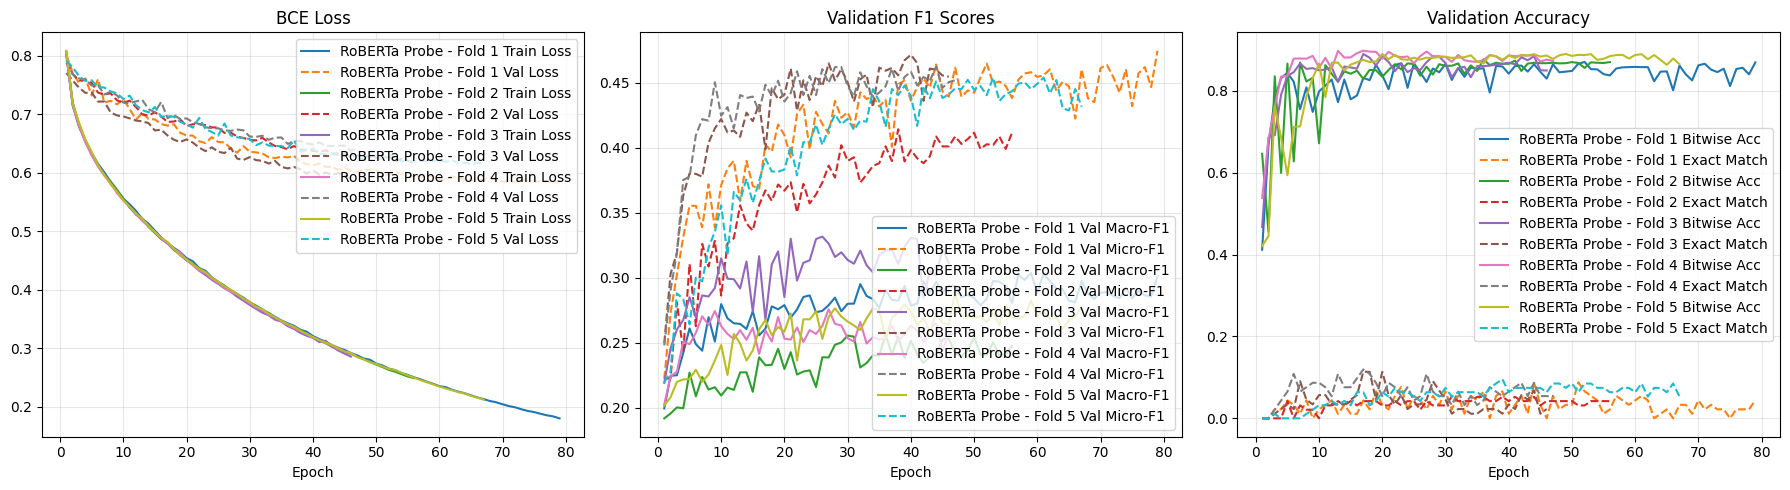


--- Cross Validation Summary (5 Folds) ---
Average Val Macro-F1: 0.291
Average Val Micro-F1: 0.440

Evaluating on Final Hold-out Test Set using model from RoBERTa Probe - Fold 3...

--- Final Test Evaluation ---
Test Macro-F1:  0.256
Test Micro-F1:  0.424
Test Accuracy:  0.853
Exact Match:    0.000


In [27]:
#apply kfold validation with the df_augmented_combined dataset kfold stratification

# Make sure you have imported the iterative stratification modules
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold, MultilabelStratifiedShuffleSplit

# Set seed & device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Setup
# ------------------------------------------------------------------------------
observed_labels = {l for ls in df_augmented_combined["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]
keep_set = set(CLASSES)
clean_labels = [
    [l for l in ls if l in keep_set]
    for ls in df_augmented_combined["labels"]
]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep all rows including ones with no label
has_label = np.ones(len(Y), dtype=bool)

#Capture the original indices from the dataframe for mapping later
texts = df_augmented_combined.loc[has_label, "text"].astype(str).tolist()
valid_df_indices = df_augmented_combined.index[has_label].to_numpy()
Y = Y[has_label]

idx = np.arange(len(texts))

# ------------------------------------------------------------------------------
# 2. Feature Extraction (Optimized: Done once for ALL text)
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=MAX_LENGTH, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features for the entire dataset...")
all_feats = extract_features(texts)

POOLING = "mean"
X_all = all_feats[POOLING]

# ------------------------------------------------------------------------------
# 3. split ORIGINAL memes,
#    then add augmented copies to the TRAIN side only
# ------------------------------------------------------------------------------
ids = df_augmented_combined.loc[has_label, "id"].astype(str)
is_aug = ids.str.endswith("_aug_de").to_numpy()
groups = ids.str.replace(r"_aug_de$", "", regex=True).to_numpy()   # aug copy -> its original's id
orig_idx = np.where(~is_aug)[0]

# extra "no technique" column, for splitting only
Y_strat = np.hstack([Y, (Y.sum(axis=1) == 0)[:, None]])

# A. Hold out 15% of ORIGINAL memes as the final test set (no augmented text in test)
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
o_tv, o_te = next(msss.split(orig_idx, Y_strat[orig_idx]))
idx_test = orig_idx[o_te]
tv_orig = orig_idx[o_tv]

X_test, y_test = X_all[idx_test], Y[idx_test]

# B. 5-fold CV on the remaining originals
K_FOLDS = 5
mskf = MultilabelStratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

cv_splits = []
for tr, va in mskf.split(tv_orig, Y_strat[tv_orig]):
    train_idx = np.where(np.isin(groups, groups[tv_orig[tr]]))[0]  # originals + their aug copies
    val_idx = tv_orig[va]                                           # originals only
    cv_splits.append((train_idx, val_idx))

experiment_splits = {
    "test_indices": valid_df_indices[idx_test].tolist(),
    "cv_folds": {}
}

# ------------------------------------------------------------------------------
# 4. K-Fold Execution Loop
# ------------------------------------------------------------------------------
fold_results = {}
fold_models = []
fold_criterions = []

all_results_fold = {} # Assuming this holds results for plot_experiments

for fold, (train_idx, val_idx) in enumerate(cv_splits):
    print(f"\n========== FOLD {fold + 1}/{K_FOLDS} ==========")

    original_train_idx = valid_df_indices[train_idx].tolist()
    original_val_idx = valid_df_indices[val_idx].tolist()
    
    experiment_splits["cv_folds"][f"fold_{fold+1}"] = {
        "train_indices": original_train_idx,
        "val_indices": original_val_idx
    }
    
    X_tr, y_train = X_all[train_idx], Y[train_idx]
    X_va, y_val = X_all[val_idx], Y[val_idx]

    # Standardize using current fold's TRAIN statistics
    mu = X_tr.mean(axis=0, keepdims=True)
    sd = X_tr.std(axis=0, keepdims=True) + 1e-6
    X_tr_norm = (X_tr - mu) / sd
    X_va_norm = (X_va - mu) / sd

    train_ds = FeatureDataset(X_tr_norm, y_train)
    val_ds = FeatureDataset(X_va_norm, y_val)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    # Dynamic pos_weights for current fold
    pos_counts = y_train.sum(axis=0)
    pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
    pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    probe_model = LinearProbe(in_features=X_tr_norm.shape[1], num_classes=len(CLASSES)).to(device)
    optimizer = optim.Adam(probe_model.parameters(), lr=1e-3)

    history, best_info = run_experiment(
        probe_model, optimizer, criterion, train_loader, val_loader,
        epochs=EPOCHS_AMT, patience=PATIENCE_AMT, name=f"Fold_{fold+1}"
    )

    # Store results for this fold
    fold_name = f"RoBERTa Probe - Fold {fold+1}"
    all_results_fold[fold_name] = {
        "history": history,
        "best_info": best_info,
    }

# Get the 0-based index of the best epoch to retrieve other metrics
    best_epoch_idx = best_info["epoch"] - 1 

    fold_results[fold_name] = {
        "macro_f1": best_info["score"], # 'score' holds the best macro_f1
        "micro_f1": history["val_micro"][best_epoch_idx], # Retrieve from history
        "thr": best_info["thr"],
        "mu": mu,
        "sd": sd
    }

    # Keep copies of models/criterions for final test set evaluation
    fold_models.append(copy.deepcopy(probe_model.state_dict()))
    fold_criterions.append(criterion)

# Plot training curves for all folds
plot_experiments(all_results_fold)

# ------------------------------------------------------------------------------
# 5. Final Evaluation
# ------------------------------------------------------------------------------
# Calculate average CV metrics
cv_macro_f1 = np.mean([res["macro_f1"] for res in fold_results.values()])
cv_micro_f1 = np.mean([res["micro_f1"] for res in fold_results.values()])

print(f"\n--- Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {cv_macro_f1:.3f}")
print(f"Average Val Micro-F1: {cv_micro_f1:.3f}")

# Select the best performing model from the CV process for the hold-out test
best_fold_idx = np.argmax([res["macro_f1"] for res in fold_results.values()])
best_fold_name = f"RoBERTa Probe - Fold {best_fold_idx+1}"
print(f"\nEvaluating on Final Hold-out Test Set using model from {best_fold_name}...")

# Normalize test set strictly using the BEST fold's statistics
best_mu = fold_results[best_fold_name]["mu"]
best_sd = fold_results[best_fold_name]["sd"]
best_thr = fold_results[best_fold_name]["thr"]

X_te_norm = (X_test - best_mu) / best_sd

test_ds = FeatureDataset(X_te_norm, y_test)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
#init model
best_model = LinearProbe(in_features=X_te_norm.shape[1], num_classes=len(CLASSES)).to(device)
#load saved state
best_model.load_state_dict(fold_models[best_fold_idx])

# Load the saved state_dict into the model
best_criterion = fold_criterions[best_fold_idx]

test_res = evaluate_model(best_model, test_loader, best_criterion, threshold=best_thr)

results_scores['RoBERTa linear Probe: train, augmented'] = {
    "macro_f1": test_res["macro_f1"],
    "micro_f1": test_res["micro_f1"],
    "accuracy": test_res["accuracy"],
    "exact_match": test_res["exact_match"],
}

print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

In [28]:
'''
################ Save the splits to disk for future experiments ################
with open("dataset_splits.json", "w") as f:
    json.dump(experiment_splits, f, indent=4)
    
print("\nSplits successfully saved to 'dataset_splits.json'")
################################################################################################

################  to load from disk ################
with open("dataset_splits.json", "r") as f:
    saved_splits = json.load(f)

# Reconstruct Test Set
test_df = df_augmented_combined.loc[saved_splits["test_indices"]]

# Reconstruct Fold 1 Train/Val sets
fold1_train = df_augmented_combined.loc[saved_splits["cv_folds"]["fold_1"]["train_indices"]]
fold1_val = df_augmented_combined.loc[saved_splits["cv_folds"]["fold_1"]["val_indices"]]
################################################################################################
'''

'\n################ Save the splits to disk for future experiments ################\nwith open("dataset_splits.json", "w") as f:\n    json.dump(experiment_splits, f, indent=4)\n    \nprint("\nSplits successfully saved to \'dataset_splits.json\'")\n################################################################################################\n\n################  to load from disk ################\nwith open("dataset_splits.json", "r") as f:\n    saved_splits = json.load(f)\n\n# Reconstruct Test Set\ntest_df = df_augmented_combined.loc[saved_splits["test_indices"]]\n\n# Reconstruct Fold 1 Train/Val sets\nfold1_train = df_augmented_combined.loc[saved_splits["cv_folds"]["fold_1"]["train_indices"]]\nfold1_val = df_augmented_combined.loc[saved_splits["cv_folds"]["fold_1"]["val_indices"]]\n################################################################################################\n'

### Step 2: Fine-tuning — Transfer learning - unfreeze the backbone and continue training the Combined Data set

Pre-tokenizing entire dataset in batch mode...

========== FOLD 1/5 ==========
Phase 1: Linear Probing (Classifier Head Only)...
[Fold_1_Probe] Epoch   1/5 | Train Loss: 0.5855 | Val Loss: 0.5319 | Val Macro-F1: 0.201 | Val Micro-F1: 0.258 | Val Acc: 0.398 | Val Exact: 0.000 | Threshold: 0.15
Transitioning to Phase 2: Injecting LoRA Adapters...
trainable params: 900,884 || all params: 125,561,896 || trainable%: 0.7175
Phase 2: Fine-Tuning with LoRA...
[Fold_1_FT_LoRA] Epoch   1/20 | Train Loss: 0.4794 | Val Loss: 0.4973 | Val Macro-F1: 0.220 | Val Micro-F1: 0.423 | Val Acc: 0.744 | Val Exact: 0.011 | Threshold: 0.20
[Fold_1_FT_LoRA] Early stopping at epoch 10. Best epoch: 5, Best Val Macro-F1: 0.320, Best Threshold: 0.40

========== FOLD 2/5 ==========
Phase 1: Linear Probing (Classifier Head Only)...
[Fold_2_Probe] Epoch   1/5 | Train Loss: 0.5649 | Val Loss: 0.5442 | Val Macro-F1: 0.184 | Val Micro-F1: 0.289 | Val Acc: 0.531 | Val Exact: 0.000 | Threshold: 0.15
Transitioning to Phase

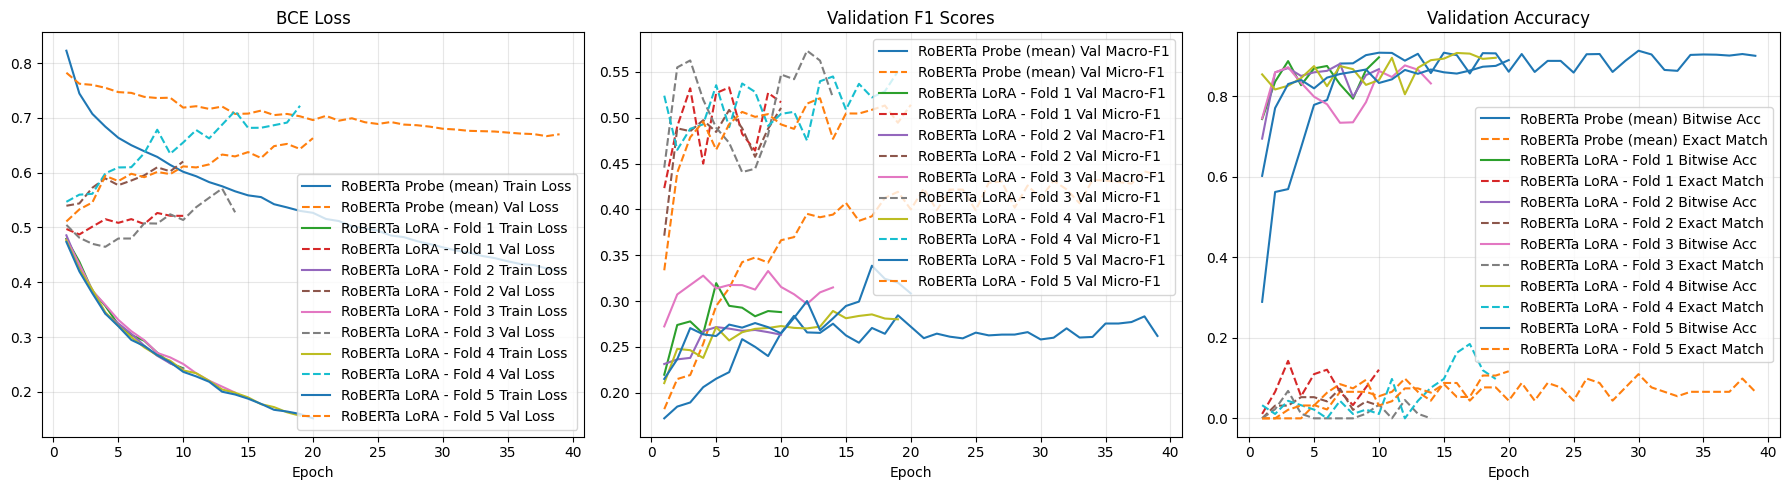


--- Cross Validation Summary (5 Folds) ---
Average Val Macro-F1: 0.310
Average Val Micro-F1: 0.509

Evaluating on Final Hold-out Test Set using model from RoBERTa LoRA - Fold 5 (Threshold: 0.300)...

--- Final Test Evaluation ---
Test Macro-F1:  0.563
Test Micro-F1:  0.676
Test Accuracy:  0.913
Exact Match:    0.202


In [31]:
# Define LoRA Configuration once so it can be reused in Step 3 and Step 4
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)


# ------------------------------------------------------------------------------
# 1. Pre-Tokenization (Done ONCE for the whole dataset)
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Pre-tokenizing entire dataset in batch mode...")
full_encodings = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

class PreTokenizedDataset(Dataset):
    def __init__(self, encodings, labels, indices):
        self.input_ids = encodings["input_ids"][indices]
        self.attention_mask = encodings["attention_mask"][indices]
        self.labels = torch.tensor(labels[indices], dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx]
        }

# ------------------------------------------------------------------------------
# 2. Re-use Data Splits from Step 1
# ------------------------------------------------------------------------------
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
idx_tv, idx_test = next(msss.split(idx, Y))

y_tv, y_test = Y[idx_tv], Y[idx_test]

# Test Dataset Setup (batch_size=16 for safety)
test_ds = PreTokenizedDataset(full_encodings, Y, idx_test)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

K_FOLDS = 5

# ------------------------------------------------------------------------------
# 3. K-Fold Execution Loop (Linear Probing -> LoRA Fine-Tuning)
# ------------------------------------------------------------------------------
fold_results = {}
fold_state_dicts = []
fold_criterions = []

for fold, (global_train_idx, global_val_idx) in enumerate(cv_splits):
    print(f"\n========== FOLD {fold + 1}/{K_FOLDS} ==========")

    train_ds = PreTokenizedDataset(full_encodings, Y, global_train_idx)
    val_ds = PreTokenizedDataset(full_encodings, Y, global_val_idx)

    # Batch size set to 16 to avoid CUDA OOM
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    # Dynamic Pos-Weights for current fold
    y_train_fold = Y[global_train_idx]
    pos_counts = y_train_fold.sum(axis=0)
    pos_weights_arr = np.sqrt((len(y_train_fold) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
    pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    # Initialize fresh base model
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(CLASSES),
        problem_type="multi_label_classification"
    ).to(device)

    # ==========================================
    # PHASE 1: LINEAR PROBING
    # ==========================================
    for param in model.base_model.parameters():
        param.requires_grad = False

    print("Phase 1: Linear Probing (Classifier Head Only)...")
    probe_optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=1e-3
    )
    
    probe_history, _ = run_experiment(
        model, probe_optimizer, criterion, train_loader, val_loader,
        epochs=5, name=f"Fold_{fold+1}_Probe"
    )

    # ==========================================
    # TRANSITION: INJECT LORA ADAPTERS
    # ==========================================
    print("Transitioning to Phase 2: Injecting LoRA Adapters...")
    
    # Clear cache to free up RAM before attaching LoRA
    torch.cuda.empty_cache()
    gc.collect()

    # Wrap the model (which now has a trained Phase 1 classifier head) with LoRA
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

    # ==========================================
    # PHASE 2: FINE-TUNING (LoRA + Classifier Head)
    # ==========================================
    print("Phase 2: Fine-Tuning with LoRA...")
    ft_optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=1e-4, 
        weight_decay=0.01
    )

    ft_history, ft_best_info = run_experiment(
        model, ft_optimizer, criterion, train_loader, val_loader,
        epochs=20, patience=5, name=f"Fold_{fold+1}_FT_LoRA"
    )

    fold_name = f"RoBERTa LoRA - Fold {fold+1}"
    all_results[fold_name] = {
        "history": ft_history,
        "best_info": ft_best_info,
    }

    best_epoch_idx = ft_best_info["epoch"] - 1

    fold_results[fold_name] = {
        "macro_f1": ft_best_info["score"],
        "micro_f1": ft_history["val_micro"][best_epoch_idx],
        "thr": ft_best_info.get("thr", 0.5),
    }

    # Store state dict on CPU to save GPU RAM
    if "best_state_dict" in ft_best_info:
        cpu_state_dict = {k: v.cpu() for k, v in ft_best_info["best_state_dict"].items()}
        fold_state_dicts.append(copy.deepcopy(cpu_state_dict))
    else:
        fold_state_dicts.append(copy.deepcopy(model.cpu().state_dict()))

    fold_criterions.append(criterion)

plot_experiments(all_results)

# ------------------------------------------------------------------------------
# 4. Final Evaluation on Hold-Out Test Set
# ------------------------------------------------------------------------------
cv_macro_f1 = np.mean([res["macro_f1"] for res in fold_results.values()])
cv_micro_f1 = np.mean([res["micro_f1"] for res in fold_results.values()])

print(f"\n--- Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {cv_macro_f1:.3f}")
print(f"Average Val Micro-F1: {cv_micro_f1:.3f}")

# Select best performing model fold
best_fold_idx = int(np.argmax([res["macro_f1"] for res in fold_results.values()]))
best_fold_name = f"RoBERTa LoRA - Fold {best_fold_idx+1}"
best_thr = fold_results[best_fold_name]["thr"]

print(f"\nEvaluating on Final Hold-out Test Set using model from {best_fold_name} (Threshold: {best_thr:.3f})...")

# 1. Initialize clean base model
best_base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(CLASSES),
    problem_type="multi_label_classification"
)

# 2. Wrap base model with LoRA so structure matches saved state dict
best_model = get_peft_model(best_base_model, lora_config).to(device)

# 3. Load saved weights into the LoRA model
best_model.load_state_dict(fold_state_dicts[best_fold_idx])
best_criterion = fold_criterions[best_fold_idx]

# Evaluate using tuned threshold
test_res = evaluate_model(best_model, test_loader, best_criterion, threshold=best_thr)

# Store results
results_scores['RoBERTa LoRA Fine-Tuned: train, augmented'] = {
    "macro_f1": test_res["macro_f1"],
    "micro_f1": test_res["micro_f1"],
    "accuracy": test_res["accuracy"],
    "exact_match": test_res["exact_match"],
}

print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

### Step 3: Fine-tuning — Regularization techniques: Best Drop out, Best Weight Decay, Optimaization: Best Learning Technique

In [32]:
import gc
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from transformers import AutoConfig, AutoModelForSequenceClassification
from peft import LoraConfig, TaskType, get_peft_model

def run_kfold_twostage(
    d_rate=0.1,
    weight_decay=0.01,
    ft_lr=1e-4,
    p1_epochs=2,
    p2_epochs=2,
    k_folds=5
):
    """
    Runs a fast K-Fold cross-validation over Phase 1 (Linear Probe) and Phase 2 (LoRA)
    for a given set of hyperparameters.
    """
    fold_f1_scores = []

    for fold, (global_train_idx, global_val_idx) in enumerate(cv_splits):

        train_ds = PreTokenizedDataset(full_encodings, Y, global_train_idx)
        val_ds = PreTokenizedDataset(full_encodings, Y, global_val_idx)

        train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

        # Class weights calculation
        y_train_fold = Y[global_train_idx]
        pos_counts = y_train_fold.sum(axis=0)
        pos_weights_arr = np.sqrt((len(y_train_fold) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
        pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

        # 1. Load RoBERTa Config with tuned Dropout Rate
        config = AutoConfig.from_pretrained(
            MODEL_NAME,
            num_labels=len(CLASSES),
            problem_type="multi_label_classification",
            classifier_dropout=d_rate,
            hidden_dropout_prob=d_rate
        )

        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            config=config
        ).to(device)

        # ----------------------------
        # PHASE 1: LINEAR PROBING
        # ----------------------------
        for param in model.base_model.parameters():
            param.requires_grad = False

        probe_optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
        
        _, _ = run_experiment(
            model, probe_optimizer, criterion, train_loader, val_loader,
            epochs=p1_epochs, name=f"Search_P1_Fold{fold+1}"
        )

        # ----------------------------
        # PHASE 2: LoRA FINE-TUNING
        # ----------------------------
        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=8,
            lora_alpha=16,
            lora_dropout=d_rate,  # Apply dropout to LoRA adapters as well
            target_modules=["query", "value"]
        )

        model = get_peft_model(model, lora_config)

        ft_optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=ft_lr,
            weight_decay=weight_decay
        )

        ft_history, ft_best_info = run_experiment(
            model, ft_optimizer, criterion, train_loader, val_loader,
            epochs=p2_epochs, patience=5, name=f"Search_P2_Fold{fold+1}"
        )

        # Save best macro F1 score for this fold
        fold_f1_scores.append(ft_best_info["score"])

        # Prevent GPU memory leak between folds
        del model, ft_optimizer, probe_optimizer, train_loader, val_loader, train_ds, val_ds
        torch.cuda.empty_cache()
        gc.collect()

    return np.mean(fold_f1_scores)

In [33]:
# 1: Best Dropout Search for RoBERTa
dropout_rates = [0.00, 0.05, 0.10, 0.15] # Adjusted for typical NLP ranges
dropout_results = {}

print("Stage 1: Tune Dropout for RoBERTa LoRA")
best_macro_f1 = -1.0
best_dropout = dropout_rates[0]

for d_rate in dropout_rates:
    print(f"\n{'='*40}")
    print(f"Testing Dropout = {d_rate}")
    print(f"{'='*40}")
    
    # Ensure reproducibility for each run
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    # ⚡ FAST SEARCH: Call your custom RoBERTa function
    # It already handles model initialization, looping folds, and VRAM cleanup
    avg_macro_f1 = run_kfold_twostage(
        d_rate=d_rate,
        weight_decay=0.01,
        ft_lr=1e-4,
        p1_epochs=2,  # Short epochs for fast search
        p2_epochs=2,  
        k_folds=5
    )
    
    dropout_results[f"Drop={d_rate}"] = avg_macro_f1
    print(f"Avg CV Macro F1 for Dropout {d_rate}: {avg_macro_f1:.4f}")
    
    # Track the best score
    if avg_macro_f1 > best_macro_f1:
        best_macro_f1 = avg_macro_f1
        best_dropout = d_rate
        
    # ⚡ PREVENT MEMORY BOTTLENECK: Clear VRAM
    torch.cuda.empty_cache()
    gc.collect()

print(f"\n✅ Best Dropout selected for Step 2: {best_dropout} (Macro F1: {best_macro_f1:.4f})")
print("Results summary:", dropout_results)

Stage 1: Tune Dropout for RoBERTa LoRA

Testing Dropout = 0.0
[Search_P1_Fold1] Epoch   1/2 | Train Loss: 0.5721 | Val Loss: 0.5319 | Val Macro-F1: 0.205 | Val Micro-F1: 0.269 | Val Acc: 0.433 | Val Exact: 0.000 | Threshold: 0.15
[Search_P2_Fold1] Epoch   1/2 | Train Loss: 0.4898 | Val Loss: 0.5041 | Val Macro-F1: 0.265 | Val Micro-F1: 0.380 | Val Acc: 0.677 | Val Exact: 0.000 | Threshold: 0.20
[Search_P1_Fold2] Epoch   1/2 | Train Loss: 0.5518 | Val Loss: 0.5456 | Val Macro-F1: 0.175 | Val Micro-F1: 0.196 | Val Acc: 0.153 | Val Exact: 0.000 | Threshold: 0.05
[Search_P2_Fold2] Epoch   1/2 | Train Loss: 0.4778 | Val Loss: 0.5228 | Val Macro-F1: 0.236 | Val Micro-F1: 0.372 | Val Acc: 0.688 | Val Exact: 0.000 | Threshold: 0.20
[Search_P1_Fold3] Epoch   1/2 | Train Loss: 0.5664 | Val Loss: 0.5414 | Val Macro-F1: 0.224 | Val Micro-F1: 0.303 | Val Acc: 0.495 | Val Exact: 0.000 | Threshold: 0.15
[Search_P2_Fold3] Epoch   1/2 | Train Loss: 0.5114 | Val Loss: 0.5226 | Val Macro-F1: 0.222 | Val 

In [ ]:

weight_decays = [0.0, 1e-4, 1e-3]
wd_results = {}
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(f"Stage 2: Tune Weight Decay (Using Best Dropout: {best_dropout})")
best_val_acc = -1.0
best_wd = weight_decays[0]

for w_d in weight_decays:
    exp_name = f"v6_WD_{w_d}"
    print(f"\nTesting Weight Decay = {w_d}")
    
    torch.manual_seed(0)
    baseline_al = create_resnet18_lf(NUM_CLASSES, dropout_rate=best_dropout).to(device)
    freeze_backbone(baseline_al)

    # ⚡ FAST SEARCH: Only 2 epochs per stage
    results, cv_models, cv_loaders = stratifiedKFold_processing_twostage(
        model=baseline_al, 
        name=exp_name, 
        train_df=train_df,                  
        seq_transform=seq_transform,        
        aug_level='light',                  
        p1_epochs=2,           
        p2_epochs=2,          
        ft_lr=1e-5,            
        wd=w_d,               
        criterion=criterion
    )
    
    wd_results[f"WD={w_d}"] = results['CV_Avg']
    avg_acc = max(results['CV_Avg']['val_acc'])
    
    if avg_acc > best_val_acc:
        best_val_acc = avg_acc
        best_wd = w_d
        
    # ⚡ PREVENT MEMORY BOTTLENECK
    del baseline_al, cv_models, cv_loaders, results
    torch.cuda.empty_cache()
    gc.collect()

print(f"\n✅ Best Weight Decay selected for Step 3: {best_wd} (Acc: {best_val_acc:.4f})")
# Optional: plot_experiments(wd_results)

### 3.3 Part B — Showing the student where

In [ ]:
#load the training data training_set_task2
# 1. Load the JSON data
with open("training_set_task2.txt", "r", encoding="utf-8") as f:
    data = json.load(f)

# 2. Extract unique labels (techniques)
unique_techniques = set()
for item in data:
    for label in item["labels"]:
        unique_techniques.add(label["technique"])

techniques_list = sorted(list(unique_techniques))
id2label = {idx: label for idx, label in enumerate(techniques_list)}
label2id = {label: idx for idx, label in enumerate(techniques_list)}

# 3. Format for Multi-Label Sequence Classification
processed_data = {"id": [], "text": [], "labels": []}
for item in data:
    processed_data["id"].append(item["id"])
    processed_data["text"].append(item["text"])
    
    # Create a multi-hot encoded binary vector for the techniques present
    label_vector = [0.0] * len(techniques_list)
    for label in item["labels"]:
        tech_idx = label2id[label["technique"]]
        label_vector[tech_idx] = 1.0
        
    processed_data["labels"].append(label_vector)

# 4. Convert to Hugging Face Dataset
hf_dataset = Dataset.from_dict(processed_data)

In [ ]:
#tokenize setup
from transformers import RobertaTokenizerFast

tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_dataset = hf_dataset.map(tokenize_function, batched=True)

* With Multi-Label Token Classification, spans can overlap for example a string might be "Name-Calling" and over lap with "Loaded Language".
* Consistency: Using two separate models can lead to contradictory predictions. For instance, the Part A model might classify a meme as containing “Name-Calling,”
  while the Part B model identifies no spans associated with that technique. Using a single model ensures that the document-level and token-level predictions maintains consistentcy.
* Efficiency: Training and maintaining a single RoBERTa model reduces memory usage and computational costs compared with training separate sequence-classification and token-classification models.
* Architecture Choice: A multi-label token-classification model, as used in Part B, can also work with Part A without requiring a separate model. If at least one token is predicted to contain a particular technique, then the meme can be considered to contain that technique. Therefore, document-level predictions can be obtained by applying a logical OR (or equivalently, taking the mathematical max()) across the token-level predictions.

In [ ]:
import torch
import torch.nn as nn
from transformers import RobertaModel, RobertaPreTrainedModel

class RobertaForMultiLabelTokenClassification(RobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        
        # Load the base RoBERTa model without the pooling layer
        self.roberta = RobertaModel(config, add_pooling_layer=False)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        
        # Classifier head: hidden_size -> num_labels (techniques)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        # 1. Pass input through RoBERTa
        outputs = self.roberta(input_ids, attention_mask=attention_mask, **kwargs)
        sequence_output = self.dropout(outputs[0]) # Shape: (batch, seq_len, hidden_size)
        
        # 2. Get logits for each token
        logits = self.classifier(sequence_output)  # Shape: (batch, seq_len, num_labels)
        
        loss = None
        if labels is not None:
            # 3. Use BCE loss for multi-label classification
            loss_fct = nn.BCEWithLogitsLoss()
            
            # 4. Filter out padding tokens using the attention mask
            active_loss = attention_mask.view(-1) == 1
            active_logits = logits.view(-1, self.num_labels)[active_loss]
            active_labels = labels.view(-1, self.num_labels)[active_loss]
            
            loss = loss_fct(active_logits, active_labels.float())
            
        return {"loss": loss, "logits": logits}

In [ ]:
from transformers import RobertaTokenizerFast
import numpy as np

# Ensure you use the Fast tokenizer to get offset mappings
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

def preprocess_spans(example, techniques_list, max_len=128):
    # 1. Tokenize text and get character offsets for each token
    encoding = tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=max_len,
        return_offsets_mapping=True
    )
    
    num_techniques = len(techniques_list)
    seq_len = len(encoding["input_ids"])
    
    # Initialize a matrix of zeros: Shape (sequence_length, num_techniques)
    token_labels = np.zeros((seq_len, num_techniques), dtype=int)
    
    # 2. Map the character spans from the JSON to the tokens
    offsets = encoding["offset_mapping"]
    
    for label_info in example.get("labels", []):
        tech_idx = techniques_list.index(label_info["technique"])
        start_char = label_info["start"]
        end_char = label_info["end"]
        
        # Iterate through the token offsets to find overlaps
        for token_idx, (token_start, token_end) in enumerate(offsets):
            # Skip special tokens ([CLS], [SEP], [PAD]) which map to (0,0)
            if token_start == 0 and token_end == 0:
                continue
                
            # If the token overlaps with the character span, tag it
            if token_start < end_char and token_end > start_char:
                token_labels[token_idx, tech_idx] = 1

    # Remove offset_mapping as it's not needed for the PyTorch forward pass
    encoding.pop("offset_mapping")
    encoding["labels"] = token_labels.tolist()
    
    return encoding


In [ ]:
######################################################

In [ ]:
'''
#### google.colab.  File paths
articles_dir = '/content/drive/MyDrive/assignment2/PTC-data/train-articles'
labels_file = '/content/drive/MyDrive/assignment2/PTC-data/train-task2-TC.labels'
'''

In [ ]:
#### File paths
articles_dir = 'PTC-data/train-articles'
labels_file = 'PTC-data/train-task2-TC.labels'

In [ ]:
#extract the text span from the articles to check with the span looks like

# 1. Read labels file directly
labels_df = pd.read_csv(
    labels_file,
    sep='\t',
    header=None,
    names=['article_id', 'label', 'start', 'end']
)
labels_df['article_id'] = labels_df['article_id'].astype(str)

# 2. Gather full article text contents
articles_data = []
for file_path in glob.glob(os.path.join(articles_dir, 'article*.txt')):
    filename = os.path.basename(file_path)
    article_id = filename.replace('article', '').replace('.txt', '')

    with open(file_path, 'r', encoding='utf-8') as file:
        text_content = file.read()

    articles_data.append({
        'article_id': article_id,
        'text': text_content
    })

articles_df = pd.DataFrame(articles_data)

# 3. Merge raw label entries with article texts
ptc_df = pd.merge(labels_df, articles_df, on='article_id', how='left')

# 4. Extract snippet by slicing text using character offsets
ptc_df['extracted_text'] = ptc_df.apply(
    lambda row: row['text'][int(row['start']):int(row['end'])] if pd.notna(row['text']) else '',
    axis=1
)

# 5. Clean up columns order
ptc_df = ptc_df[['article_id', 'label', 'start', 'end', 'extracted_text']]

# Display result
display(ptc_df.head())

We can see that the context is lost if only extracting the span text related to the label. MinD in (Da San Martino et al., 2020) mentions that there models performed particulary bad on certain labels such as "Repetition" (page 1086. Table. 7), Red Herring. They also used Sentence Boundary Segmentation where the split of the text is at the sentence level encapsulating the label position span and the start and end of that sentence.


In [ ]:

# Ensure the punkt tokenizer models are downloaded
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
tokenizer = PunktSentenceTokenizer()


# 1. Read labels file directly
labels_df = pd.read_csv(
    labels_file,
    sep='\t',
    header=None,
    names=['article_id', 'label', 'start', 'end']
)
labels_df['article_id'] = labels_df['article_id'].astype(str)

# 2. Gather full article texts AND perform sentence segmentation
sentence_data = []
for file_path in glob.glob(os.path.join(articles_dir, 'article*.txt')):
    filename = os.path.basename(file_path)
    article_id = filename.replace('article', '').replace('.txt', '')

    with open(file_path, 'r', encoding='utf-8') as file:
        text_content = file.read()

    # Use span_tokenize to get the start and end character indices of each sentence
    for sent_start, sent_end in tokenizer.span_tokenize(text_content):
        sentence_data.append({
            'article_id': article_id,
            'sent_start': sent_start,
            'sent_end': sent_end,
            'sentence_text': text_content[sent_start:sent_end]
        })

sentences_df = pd.DataFrame(sentence_data)

# 3. Create a dictionary of labels grouped by article_id for fast lookup
labels_dict = (
    labels_df.groupby('article_id')
    .apply(lambda x: x[['label', 'start', 'end']].to_dict('records'))
    .to_dict()
)

# 4. Map labels to sentences based on character offset overlap
def map_labels_to_sentence(row):
    art_id = row['article_id']
    sent_start = row['sent_start']
    sent_end = row['sent_end']

    if art_id not in labels_dict:
        return []

    matched_labels = []
    for lbl in labels_dict[art_id]:
        lbl_start = int(lbl['start'])
        lbl_end = int(lbl['end'])

        # Check for overlap: if max of starts < min of ends, the text spans intersect
        if max(sent_start, lbl_start) < min(sent_end, lbl_end):
            matched_labels.append(lbl['label'])

    # Return unique labels (in case multiple spans in one sentence have the same label)
    return list(set(matched_labels))

sentences_df['labels'] = sentences_df.apply(map_labels_to_sentence, axis=1)

# 5. Clean up columns and filter out sentences with no text (e.g., standalone newlines)
sentences_df = sentences_df[['article_id', 'sent_start', 'sent_end', 'sentence_text', 'labels']]
sentences_df = sentences_df[sentences_df['sentence_text'].str.strip().astype(bool)]

# Display result
display(sentences_df.head(10))

In [ ]:
#filter out empty label entries from sentence_df
positive_sentences_df = sentences_df[sentences_df['labels'].map(len) > 0].reset_index(drop=True)
display(positive_sentences_df.head())

some of the data has bad unnormal characters such as:

    "‚Äî bishops have a very grave responsibility."
These will be removed as they could cause issues in the model training


In [ ]:
positive_sentences_df['sentence_text'] = positive_sentences_df['sentence_text'].apply(ftfy.fix_text)
display(positive_sentences_df.head())

In [ ]:
print(positive_sentences_df.columns.tolist())

There are still issues that can be seen in the samples, example:
Article: 699478811,
label:['Appeal_to_fear-prejudice'],
text:  "Thus, it is threatening U.S."
From the main text: "Thus, it is threatening U.S. forces and bases in the region."

We can see that the sentence extraction logic has ended the sentence prematurally due to the full stop after U.S, "." and not included forces. This can be tricky as it is gramatically should be "threatening U.S forces..." hence it is not perfect but maybe there are enough good samples to over come the misleading cases.

In [ ]:
'''
#### google.colab. save to file
from google.colab import files
folder_path = "/content/drive/MyDrive/assignment2"
positive_sentences_df.to_csv(f"{folder_path}/positive_sentences_df.csv", index=False)
'''

In [ ]:
#positive_sentences_df = positive_sentences_df.to_frame()

In [ ]:
#align the ptc_df so that it has the same names as DF (training_set_task1.txt) so that a comparison can be done
#mapping from current PTC labels -> desired label names
label_mapping = {
    "Appeal_to_Authority": "Appeal to authority",
    "Appeal_to_fear-prejudice": "Appeal to fear/prejudice",
    "Black-and-White_Fallacy": "Black-and-white Fallacy/Dictatorship",
    "Causal_Oversimplification": "Causal Oversimplification",
    "Exaggeration": "Exaggeration/Minimisation",
    "Flag-Waving": "Flag-waving",
    "Loaded_Language": "Loaded Language",
    "Straw_Men": "Misrepresentation of Someone's Position (Straw Man)",
    "Labeling": "Name calling/Labeling",
    "Name_Calling": "Name calling/Labeling",
    "Red_Herring": "Presenting Irrelevant Data (Red Herring)",
    "Reductio_ad_hitlerum": "Reductio ad hitlerum",
    "Thought-terminating_Cliches": "Thought-terminating cliché",
    "Minimisation": "Exaggeration/Minimisation"
}

#update labels in ptc_df
def update_labels(labels):
    updated = []

    for label in labels:
        #some entries contain multiple labels separated by commas
        for individual_label in str(label).split(","):
            individual_label = individual_label.strip()

            #replace with desired name if it exists in the mapping
            updated.append(
                label_mapping.get(individual_label, individual_label)
            )

    return updated


positive_sentences_df["labels"] = positive_sentences_df["labels"].apply(update_labels)

In [ ]:
#show the class counts of DF (training_set_task1.txt)
ptc_label_counts = (
    positive_sentences_df["labels"]
    .dropna()
    .explode()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

print(ptc_label_counts)

In [ ]:
# -----------------------------
# DF class counts
# -----------------------------
df_counts = (
    df["labels"]
    .dropna()
    .explode()
    .value_counts()
    .reindex(df_labels, fill_value=0)
)

# -----------------------------
# PTC class counts
# -----------------------------
ptc_counts = (
    positive_sentences_df["labels"]
    .dropna()
    .explode()
    .value_counts()
    .reindex(df_labels, fill_value=0)
)

# -----------------------------
# Combine into one table
# -----------------------------
class_counts = pd.DataFrame({
    "Label": df_labels,
    "DF Count": df_counts.values,
    "PTC Count": ptc_counts.values
})

# Add total count
class_counts["Total"] = class_counts["DF Count"] + class_counts["PTC Count"]

display(class_counts)

* The thing to consider is that the lists are made up of single and multi labeled samples, so for instance in PTC Count-> Exaggeration had 171, and Minimisation had 171, as a result of being joined the total is 342.
* The Total column shows the new qty for the class if we join the new data to the existing samples. Although it is still imbalanced it provides more to work with.
* Also there are still empty classes "Transfer" and "Appeal to (Strong) Emotions"


In [ ]:
#print off a few from df to see that format difference
df = df.sort_values(by='id')
display(df.head())

In [ ]:
#print off a few from df to see that format difference
ptc_df_show = positive_sentences_df.sort_values(by='article_id')
display(ptc_df_show.head())

In [ ]:
#combine text sentence instances so that sentences with multiple labels are grouped together,
#with all associated labels stored as a list. This is so that there isn't duplicated

# 1. Create normalized text key on positive_sentences_df
positive_sentences_df["text_key"] = (
    positive_sentences_df["sentence_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# 2. Group by text_key to combine duplicate sentences and flatten their labels
positive_sentences_grouped = (
    positive_sentences_df.groupby("text_key", as_index=False)
    .agg({
        "article_id": "first",
        "sentence_text": "first",
        "labels": lambda label_series: list(dict.fromkeys(
            lbl
            for item in label_series
            for lbl in (item if isinstance(item, list) else [item])
            if lbl
        ))
    })
)


In [ ]:
display(positive_sentences_df.head())

In [ ]:
# -----------------------------
# Create normalised text keys
# -----------------------------
'''
positive_sentences_df["text_key"] = (
    positive_sentences_df["sentence_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)'''

df["text_key"] = (
    df["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# -----------------------------
# Merge grouped PTC sentences with DF
# -----------------------------
combined_df = pd.merge(
    positive_sentences_grouped.rename(columns={"sentence_text": "text"}),
    df[["id", "text", "labels", "text_key"]],
    on="text_key",
    how="outer",
    suffixes=("_ptc", "_df")
)

# -----------------------------
# Consolidate text and labels
# -----------------------------
combined_df["text"] = combined_df["text_ptc"].combine_first(combined_df["text_df"])

def combine_row_labels(row):
    ptc_lbls = row["labels_ptc"] if isinstance(row["labels_ptc"], list) else []
    df_lbls = row["labels_df"] if isinstance(row["labels_df"], list) else ([row["labels_df"]] if pd.notna(row["labels_df"]) else [])
    return list(dict.fromkeys(ptc_lbls + df_lbls))

combined_df["labels"] = combined_df.apply(combine_row_labels, axis=1)


combined_df = combined_df[combined_df["labels"].apply(len) > 0].reset_index(drop=True)
combined_df = combined_df[["article_id", "id", "text", "labels"]]

display(combined_df.head())

In [ ]:
display(
    combined_df[combined_df["id"].notna()].head(5)
)

In [ ]:
#display counts of new df combined
combined_df_show = (
    combined_df["labels"]
    .dropna()
    .explode()
    .value_counts()
    .reindex(df_labels, fill_value=0)
)
display(combined_df_show)

In [ ]:
'''
#### google.colab.  save to file
from google.colab import files
folder_path = "/content/drive/MyDrive/assignment2"
combined_df.to_csv(f"{folder_path}/combined.csv", index=False)
'''

99% of your texts have 104 tokens or fewer.
max_length is set to 128 should suffice

In [ ]:
#check the size of the number of tokens for the combined dataset "combined_df"
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# Tokenize all texts without truncating or padding
tokenized_data = tokenizer(combined_df["text"].astype(str).tolist(), add_special_tokens=True)

# Count the tokens in each sequence
token_lengths = [len(seq) for seq in tokenized_data["input_ids"]]

# Find the absolute maximum
max_tokens = max(token_lengths)
print(f"The longest text has {max_tokens} tokens.")

# Optional: View the distribution to see if the max is just an outlier
lengths_series = pd.Series(token_lengths)
print("\nToken Length Distribution:")
print(lengths_series.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

In [ ]:
#[2]base linear probing RoBERTa combined data set

# Set seed & device
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Split
# ------------------------------------------------------------------------------
# Filter out classes with 0 positives and ensure clean lists
observed_labels = {l for ls in combined_df["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]

keep_set = set(CLASSES)
clean_labels = [
    [l for l in ls if l in keep_set]
    for ls in combined_df["labels"]
]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep rows with at least one target class
has_label = Y.sum(axis=1) > 0
texts = combined_df.loc[has_label, "text"].astype(str).tolist()
Y = Y[has_label]

idx = np.arange(len(texts))

#MultilabelStratifiedShuffleSplit
tr, tmp = next(MSSS(n_splits=1, test_size=0.30, random_state=SEED).split(idx, Y))
v, t = next(MSSS(n_splits=1, test_size=0.50, random_state=SEED).split(tmp, Y[tmp]))
va, te = tmp[v], tmp[t]

X_tr_text, y_train = [texts[i] for i in tr], Y[tr]
X_va_text, y_val = [texts[i] for i in va], Y[va]
X_te_text, y_test = [texts[i] for i in te], Y[te]

# ------------------------------------------------------------------------------
# 2. Feature Extraction & Normalization
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=MAX_LENGTH, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features...")
train_feats = extract_features(X_tr_text)
val_feats = extract_features(X_va_text)
test_feats = extract_features(X_te_text)

# Choose pooling type ('mean' or 'cls')
POOLING = "mean"
X_tr, X_va, X_te = train_feats[POOLING], val_feats[POOLING], test_feats[POOLING]

# Standardize using TRAIN statistics only
mu, sd = X_tr.mean(axis=0, keepdims=True), X_tr.std(axis=0, keepdims=True) + 1e-6
X_tr_norm = (X_tr - mu) / sd
X_va_norm = (X_va - mu) / sd
X_te_norm = (X_te - mu) / sd

# ------------------------------------------------------------------------------
# 3. Dataset & Model Definition
# ------------------------------------------------------------------------------

train_ds = FeatureDataset(X_tr_norm, y_train)
val_ds = FeatureDataset(X_va_norm, y_val)
test_ds = FeatureDataset(X_te_norm, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# Tamed pos_weights calculation
pos_counts = y_train.sum(axis=0)
pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)

#BCEWithLogitsLoss is used for multi label classification - to handle multiple independant tags at the same time
#pos_weight only applies to +'ve weights of a particular class and balances the ratio of the single binary decision:
#for example - ground truth =1 -> loss is x's pos_weight, else =0 -> weight not applied, hence focuses on the things
#that are in label setup
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)


# ------------------------------------------------------------------------------
# 4. Metric Utilities & Training Functions
# ------------------------------------------------------------------------------
THRESHOLDS = np.arange(0.05, 0.96, 0.05)


# ------------------------------------------------------------------------------
# 5. Execution
# ------------------------------------------------------------------------------
probe_model = LinearProbe(in_features=X_tr_norm.shape[1], num_classes=len(CLASSES)).to(device)
optimizer = optim.Adam(probe_model.parameters(), lr=1e-3)

history, best_info = run_experiment(
    probe_model, optimizer, criterion, train_loader, val_loader,
    epochs=300, patience=40, name=f"RoBERTa Probe combined ({POOLING})"
)

all_results[f"RoBERTa Probe combined ({POOLING})"] = {
    "history": history,
    "best_info": best_info
}
plot_experiments(all_results)

# Final Test Evaluation with best threshold selected on validation data
test_res = evaluate_model(probe_model, test_loader, criterion)
print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

In [ ]:
#apply kfold validation

# Make sure you have imported the iterative stratification modules
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold, MultilabelStratifiedShuffleSplit

# Set seed & device
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Setup
# ------------------------------------------------------------------------------
observed_labels = {l for ls in combined_df["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]
keep_set = set(CLASSES)
clean_labels = [
    [l for l in ls if l in keep_set]
    for ls in combined_df["labels"]
]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep rows with at least one target class
has_label = Y.sum(axis=1) > 0
texts = combined_df.loc[has_label, "text"].astype(str).tolist()
Y = Y[has_label]

idx = np.arange(len(texts))

# ------------------------------------------------------------------------------
# 2. Feature Extraction (Optimized: Done once for ALL text)
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=128, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features for the entire dataset...")
all_feats = extract_features(texts)

POOLING = "mean"
X_all = all_feats[POOLING]

# ------------------------------------------------------------------------------
# 3. K-Fold Data Splitting Setup
# ------------------------------------------------------------------------------
# A. Hold out a 15% Final Test Set first
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
idx_tv, idx_test = next(msss.split(idx, Y))

X_tv, y_tv = X_all[idx_tv], Y[idx_tv]
X_test, y_test = X_all[idx_test], Y[idx_test]

# B. Setup 5-Fold Cross Validation on the remaining 85% Train/Val data
K_FOLDS = 5
mskf = MultilabelStratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

# ------------------------------------------------------------------------------
# 4. K-Fold Execution Loop
# ------------------------------------------------------------------------------
fold_results = {}
fold_models = []
fold_criterions = []

all_results = {} # Assuming this holds results for plot_experiments

for fold, (train_idx, val_idx) in enumerate(mskf.split(X_tv, y_tv)):
    print(f"\n========== FOLD {fold + 1}/{K_FOLDS} ==========")

    X_tr, y_train = X_tv[train_idx], y_tv[train_idx]
    X_va, y_val = X_tv[val_idx], y_tv[val_idx]

    # Standardize using current fold's TRAIN statistics
    mu = X_tr.mean(axis=0, keepdims=True)
    sd = X_tr.std(axis=0, keepdims=True) + 1e-6
    X_tr_norm = (X_tr - mu) / sd
    X_va_norm = (X_va - mu) / sd

    train_ds = FeatureDataset(X_tr_norm, y_train)
    val_ds = FeatureDataset(X_va_norm, y_val)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    # Dynamic pos_weights for current fold
    pos_counts = y_train.sum(axis=0)
    pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
    pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    probe_model = LinearProbe(in_features=X_tr_norm.shape[1], num_classes=len(CLASSES)).to(device)
    optimizer = optim.Adam(probe_model.parameters(), lr=1e-3)

    history, best_info = run_experiment(
        probe_model, optimizer, criterion, train_loader, val_loader,
        epochs=300, patience=40, name=f"Fold_{fold+1}"
    )

    # Store results for this fold
    fold_name = f"RoBERTa Probe - Fold {fold+1}"
    all_results[fold_name] = {
        "history": history,
        "best_info": best_info,
    }

# Get the 0-based index of the best epoch to retrieve other metrics
    best_epoch_idx = best_info["epoch"] - 1 

    fold_results[fold_name] = {
        "macro_f1": best_info["score"], # 'score' holds the best macro_f1
        "micro_f1": history["val_micro"][best_epoch_idx], # Retrieve from history
        "mu": mu,
        "sd": sd
    }

    # Keep copies of models/criterions for final test set evaluation
    fold_models.append(copy.deepcopy(probe_model))
    fold_criterions.append(criterion)

# Plot training curves for all folds
plot_experiments(all_results)

# ------------------------------------------------------------------------------
# 5. Final Evaluation
# ------------------------------------------------------------------------------
# Calculate average CV metrics
cv_macro_f1 = np.mean([res["macro_f1"] for res in fold_results.values()])
cv_micro_f1 = np.mean([res["micro_f1"] for res in fold_results.values()])

print(f"\n--- Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {cv_macro_f1:.3f}")
print(f"Average Val Micro-F1: {cv_micro_f1:.3f}")

# Select the best performing model from the CV process for the hold-out test
best_fold_idx = np.argmax([res["macro_f1"] for res in fold_results.values()])
best_fold_name = f"RoBERTa Probe - Fold {best_fold_idx+1}"
print(f"\nEvaluating on Final Hold-out Test Set using model from {best_fold_name}...")

# Normalize test set strictly using the BEST fold's statistics
best_mu = fold_results[best_fold_name]["mu"]
best_sd = fold_results[best_fold_name]["sd"]
X_te_norm = (X_test - best_mu) / best_sd

test_ds = FeatureDataset(X_te_norm, y_test)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

best_model = fold_models[best_fold_idx]
best_criterion = fold_criterions[best_fold_idx]

test_res = evaluate_model(best_model, test_loader, best_criterion)
print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

In [ ]:
###########################

In [ ]:
!pip install Levenshtein
!pip install sentencepiece
!pip install sacremoses

In [ ]:
#process used in Ng et al. (2019) subsequently used in (Ghadery et al., 2021) - 
#"LIIR at SemEval-2021 task 6: Detection of Persuasion Techniques In Texts and Images using CLIP features"


# 1. Translation helper using Facebook WMT19 models
def translate(text, model_name, sample=False):
    # Use Auto classes as WMT19 uses FSMT architecture, not Marian
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    
    # Introduce sampling to create variation rather than exact literal matches
    if sample:
        outputs = model.generate(
            **inputs, 
            do_sample=True, 
            temperature=0.8, 
            top_p=0.9,
            max_new_tokens=50
        )
    else:
        outputs = model.generate(**inputs, max_new_tokens=50)
        
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Run back-translation using the models referenced in the paper
original = "If Trump isn't Hitler, Then I'm a Moron"

# English to German (Standard generation)
german = translate(original, "facebook/wmt19-en-de")

# German back to English (Enable sampling here to force varied phrasing)
back_translated = translate(german, "facebook/wmt19-de-en", sample=True)

print(f"German: {german}")
print(f"Back-translated: {back_translated}\n")

# 2. Validation Metrics
edit_distance = Levenshtein.distance(original, back_translated)

bleu_score = nltk.translate.bleu_score.sentence_bleu(
    [original.lower().split()], 
    back_translated.lower().split(),
    weights=(0.5, 0.5, 0, 0)
)

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform([original, back_translated])
semantic_similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

print(f"Original: {original}")
print(f"Paraphrase: {back_translated}")
print(f"Edit Distance: {edit_distance}")
print(f"BLEU Overlap: {bleu_score:.4f}")
print(f"Semantic Similarity: {semantic_similarity:.4f}")

In [ ]:
#add the augmented data to the combined_df which is the PTC sentance data set and the df
#apply kfold validation with the df_augmented_combined dataset kfold stratification

#combine unique augmented to 
df_ptc_augmented_combined = pd.concat([combined_df, df_aug_filtered], ignore_index=True)
print(f"Final combined - df,ptc-aug dataset size: {len(df_ptc_augmented_combined)}")


# Make sure you have imported the iterative stratification modules
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold, MultilabelStratifiedShuffleSplit

# Set seed & device
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Setup
# ------------------------------------------------------------------------------
observed_labels = {l for ls in df_ptc_augmented_combined["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]
keep_set = set(CLASSES)
clean_labels = [
    [l for l in ls if l in keep_set]
    for ls in df_ptc_augmented_combined["labels"]
]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep rows with at least one target class
has_label = Y.sum(axis=1) > 0
texts = df_ptc_augmented_combined.loc[has_label, "text"].astype(str).tolist()
Y = Y[has_label]

idx = np.arange(len(texts))

# ------------------------------------------------------------------------------
# 2. Feature Extraction (Optimized: Done once for ALL text)
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=128, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features for the entire dataset...")
all_feats = extract_features(texts)

POOLING = "mean"
X_all = all_feats[POOLING]

# ------------------------------------------------------------------------------
# 3. K-Fold Data Splitting Setup
# ------------------------------------------------------------------------------
# A. Hold out a 15% Final Test Set first
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
idx_tv, idx_test = next(msss.split(idx, Y))

X_tv, y_tv = X_all[idx_tv], Y[idx_tv]
X_test, y_test = X_all[idx_test], Y[idx_test]

# B. Setup 5-Fold Cross Validation on the remaining 85% Train/Val data
K_FOLDS = 5
mskf = MultilabelStratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

# ------------------------------------------------------------------------------
# 4. K-Fold Execution Loop
# ------------------------------------------------------------------------------
fold_results = {}
fold_models = []
fold_criterions = []

all_results = {} # Assuming this holds results for plot_experiments

for fold, (train_idx, val_idx) in enumerate(mskf.split(X_tv, y_tv)):
    print(f"\n========== FOLD {fold + 1}/{K_FOLDS} ==========")

    X_tr, y_train = X_tv[train_idx], y_tv[train_idx]
    X_va, y_val = X_tv[val_idx], y_tv[val_idx]

    # Standardize using current fold's TRAIN statistics
    mu = X_tr.mean(axis=0, keepdims=True)
    sd = X_tr.std(axis=0, keepdims=True) + 1e-6
    X_tr_norm = (X_tr - mu) / sd
    X_va_norm = (X_va - mu) / sd

    train_ds = FeatureDataset(X_tr_norm, y_train)
    val_ds = FeatureDataset(X_va_norm, y_val)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    # Dynamic pos_weights for current fold
    pos_counts = y_train.sum(axis=0)
    pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
    pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    probe_model = LinearProbe(in_features=X_tr_norm.shape[1], num_classes=len(CLASSES)).to(device)
    optimizer = optim.Adam(probe_model.parameters(), lr=1e-3)

    history, best_info = run_experiment(
        probe_model, optimizer, criterion, train_loader, val_loader,
        epochs=300, patience=40, name=f"Fold_{fold+1}"
    )

    # Store results for this fold
    fold_name = f"RoBERTa Probe - Fold {fold+1}"
    all_results[fold_name] = {
        "history": history,
        "best_info": best_info,
    }

# Get the 0-based index of the best epoch to retrieve other metrics
    best_epoch_idx = best_info["epoch"] - 1 

    fold_results[fold_name] = {
        "macro_f1": best_info["score"], # 'score' holds the best macro_f1
        "micro_f1": history["val_micro"][best_epoch_idx], # Retrieve from history
        "mu": mu,
        "sd": sd
    }

    # Keep copies of models/criterions for final test set evaluation
    fold_models.append(copy.deepcopy(probe_model))
    fold_criterions.append(criterion)

# Plot training curves for all folds
plot_experiments(all_results)

# ------------------------------------------------------------------------------
# 5. Final Evaluation
# ------------------------------------------------------------------------------
# Calculate average CV metrics
cv_macro_f1 = np.mean([res["macro_f1"] for res in fold_results.values()])
cv_micro_f1 = np.mean([res["micro_f1"] for res in fold_results.values()])

print(f"\n--- Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {cv_macro_f1:.3f}")
print(f"Average Val Micro-F1: {cv_micro_f1:.3f}")

# Select the best performing model from the CV process for the hold-out test
best_fold_idx = np.argmax([res["macro_f1"] for res in fold_results.values()])
best_fold_name = f"RoBERTa Probe - Fold {best_fold_idx+1}"
print(f"\nEvaluating on Final Hold-out Test Set using model from {best_fold_name}...")

# Normalize test set strictly using the BEST fold's statistics
best_mu = fold_results[best_fold_name]["mu"]
best_sd = fold_results[best_fold_name]["sd"]
X_te_norm = (X_test - best_mu) / best_sd

test_ds = FeatureDataset(X_te_norm, y_test)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

best_model = fold_models[best_fold_idx]
best_criterion = fold_criterions[best_fold_idx]

test_res = evaluate_model(best_model, test_loader, best_criterion)
print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

In [ ]:
#LoRA / QLoRA (PEFT):
from peft import LoraConfig, get_peft_model, TaskType




In [ ]:
#######original baseline########
'''
#split the new data set that includes augmented data into train/test and validation
# Set seed & device
SEED = 42
np.random.seed(SEED)
# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Split
# ------------------------------------------------------------------------------
# Filter out classes with 0 positives and ensure clean lists
observed_labels = {l for ls in df["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]

keep_set = set(CLASSES)
clean_labels = [[l for l in ls if l in keep_set] for ls in df["labels"]]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep rows with at least one target class
has_label = Y.sum(axis=1) > 0
texts = [t for t, k in zip(df["text"].astype(str), has_label) if k]
Y = Y[has_label]

idx = np.arange(len(texts))

#MultilabelStratifiedShuffleSplit
tr, tmp = next(MSSS(n_splits=1, test_size=0.30, random_state=SEED).split(idx, Y))
v, t = next(MSSS(n_splits=1, test_size=0.50, random_state=SEED).split(tmp, Y[tmp]))
va, te = tmp[v], tmp[t]

X_tr_text, y_train = [texts[i] for i in tr], Y[tr]
X_va_text, y_val = [texts[i] for i in va], Y[va]
X_te_text, y_test = [texts[i] for i in te], Y[te]
'''

### There are 2 labels missing from your results:
    * Transfer
    * Appeal to (Strong) Emotions
    * according to the expirment these two techiques are not applicable to task 1 and task 2 (Dimitrov et al. (2021))

In [ ]:
#print off a few of the ones that had no labels
empty_labels_df.head()

word order carries meaning. Important

###Bibiography

@misc{dimitrov2021semeval2021task6detection,
      title={SemEval-2021 Task 6: Detection of Persuasion Techniques in Texts and Images},
      author={Dimitar Dimitrov and Bishr Bin Ali and Shaden Shaar and Firoj Alam and Fabrizio Silvestri and Hamed Firooz and Preslav Nakov and Giovanni Da San Martino},
      year={2021},
      eprint={2105.09284},
      archivePrefix={arXiv},
      primaryClass={cs.MM},
      url={https://arxiv.org/abs/2105.09284},
}


@misc{gupta2021voltasemeval2021task6,
      title={Volta at SemEval-2021 Task 6: Towards Detecting Persuasive Texts and Images using Textual and Multimodal Ensemble},
      author={Kshitij Gupta and Devansh Gautam and Radhika Mamidi},
      year={2021},
      eprint={2106.00240},
      archivePrefix={arXiv},
      primaryClass={cs.CL},
      url={https://arxiv.org/abs/2106.00240},
}


@inproceedings{tian-etal-2021-mind,
    title = "{M}in{D} at {S}em{E}val-2021 Task 6: Propaganda Detection using Transfer Learning and Multimodal Fusion",
    author = "Tian, Junfeng  and
      Gui, Min  and
      Li, Chenliang  and
      Yan, Ming  and
      Xiao, Wenming",
    editor = "Palmer, Alexis  and
      Schneider, Nathan  and
      Schluter, Natalie  and
      Emerson, Guy  and
      Herbelot, Aurelie  and
      Zhu, Xiaodan",
    booktitle = "Proceedings of the 15th International Workshop on Semantic Evaluation (SemEval-2021)",
    month = aug,
    year = "2021",
    address = "Online",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2021.semeval-1.150/",
    doi = "10.18653/v1/2021.semeval-1.150",
    pages = "1082--1087",
    abstract = "We describe our systems of subtask1 and subtask3 for SemEval-2021 Task 6 on Detection of Persuasion Techniques in Texts and Images. The purpose of subtask1 is to identify propaganda techniques given textual content, and the goal of subtask3 is to detect them given both textual and visual content. For subtask1, we investigate transfer learning based on pre-trained language models (PLMs) such as BERT, RoBERTa to solve data sparsity problems. For subtask3, we extract heterogeneous visual representations (i.e., face features, OCR features, and multimodal representations) and explore various multimodal fusion strategies to combine the textual and visual representations. The official evaluation shows our ensemble model ranks 1st for subtask1 and 2nd for subtask3."
}



@InProceedings{EMNLP19DaSanMartino,
author = {Da San Martino, Giovanni and
Yu, Seunghak and
Barr\'{o}n-Cede\~no, Alberto and
Petrov, Rostislav and
Nakov, Preslav},
title = {Fine-Grained Analysis of Propaganda in News Articles},
booktitle = {Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing and 9th International Joint Conference on Natural Language Processing, EMNLP-IJCNLP 2019, Hong Kong, China, November 3-7, 2019},
series = {EMNLP-IJCNLP 2019},
year = {2019},
address = {Hong Kong, China},
month = {November},
}


@inproceedings{da-san-martino-etal-2020-semeval,
    title = "{S}em{E}val-2020 Task 11: Detection of Propaganda Techniques in News Articles",
    author = "Da San Martino, Giovanni  and
      Barr{\'o}n-Cede{\~n}o, Alberto  and
      Wachsmuth, Henning  and
      Petrov, Rostislav  and
      Nakov, Preslav",
    editor = "Herbelot, Aurelie  and
      Zhu, Xiaodan  and
      Palmer, Alexis  and
      Schneider, Nathan  and
      May, Jonathan  and
      Shutova, Ekaterina",
    booktitle = "Proceedings of the Fourteenth Workshop on Semantic Evaluation",
    month = dec,
    year = "2020",
    address = "Barcelona (online)",
    publisher = "International Committee for Computational Linguistics",
    url = "https://aclanthology.org/2020.semeval-1.186/",
    doi = "10.18653/v1/2020.semeval-1.186",
    pages = "1377--1414",
    abstract = "We present the results and the main findings of SemEval-2020 Task 11 on Detection of Propaganda Techniques in News Articles. The task featured two subtasks. Subtask SI is about Span Identification: given a plain-text document, spot the specific text fragments containing propaganda. Subtask TC is about Technique Classification: given a specific text fragment, in the context of a full document, determine the propaganda technique it uses, choosing from an inventory of 14 possible propaganda techniques. The task attracted a large number of participants: 250 teams signed up to participate and 44 made a submission on the test set. In this paper, we present the task, analyze the results, and discuss the system submissions and the methods they used. For both subtasks, the best systems used pre-trained Transformers and ensembles."
}

@inproceedings{daval-frerot-weis-2020-wmd,
    title = "{WMD} at {S}em{E}val-2020 Tasks 7 and 11: Assessing Humor and Propaganda Using Unsupervised Data Augmentation",
    author = "Daval-Frerot, Guillaume  and
      Weis, Yannick",
    editor = "Herbelot, Aurelie  and
      Zhu, Xiaodan  and
      Palmer, Alexis  and
      Schneider, Nathan  and
      May, Jonathan  and
      Shutova, Ekaterina",
    booktitle = "Proceedings of the Fourteenth Workshop on Semantic Evaluation",
    month = dec,
    year = "2020",
    address = "Barcelona (online)",
    publisher = "International Committee for Computational Linguistics",
    url = "https://aclanthology.org/2020.semeval-1.246/",
    doi = "10.18653/v1/2020.semeval-1.246",
    pages = "1865--1874",
    abstract = "In this work, we combine the state-of-the-art BERT architecture with the semi-supervised learning technique UDA in order to exploit unlabeled raw data to assess humor and detect propaganda in the tasks 7 and 11 of the SemEval-2020 competition. The use of UDA shows promising results with a systematic improvement of the performances over the four different subtasks, and even outperforms supervised learning with the additional labels of the Funlines dataset."
}

@misc{ghadery2021liirsemeval2021task6,
      title={LIIR at SemEval-2021 task 6: Detection of Persuasion Techniques In Texts and Images using CLIP features}, 
      author={Erfan Ghadery and Damien Sileo and Marie-Francine Moens},
      year={2021},
      eprint={2105.14774},
      archivePrefix={arXiv},
      primaryClass={cs.CL},
      url={https://arxiv.org/abs/2105.14774}, 
}